🚀 ASYLUM SEEKERS PREDICTION MODEL

❌ File not found: /content/drive/MyDrive/Colab Notebooks/asylum_dataset.csv

📝 Creating sample dataset for demonstration...

✅ Sample dataset created with:
   Countries: 20
   Years: 24
   Total records: 480

📊 Handling missing values...
  Defence_GDP_Percent: 23 → 0 missing values
  Asylum_Seekers: 0 → 0 missing values

🔧 Encoding categorical variables...
📅 Creating time-based features...
⏰ Creating lag features...
📈 Creating rolling statistics...

✅ Final dataset shape: (480, 14)
✅ Features created: ['Year', 'Country', 'Asylum_Seekers', 'Defence_GDP_Percent', 'Country_Encoded', 'Year_Scaled', 'Defence_GDP_Lag_1', 'Asylum_Lag_1', 'Defence_GDP_Lag_2', 'Asylum_Lag_2', 'Defence_GDP_Lag_3', 'Asylum_Lag_3', 'Defence_GDP_Rolling_Mean_3', 'Asylum_Rolling_Mean_3']

📋 Sample of Processed Data:
     Year    Country  Asylum_Seekers  Defence_GDP_Percent  Country_Encoded  \
120  2000  Australia           40899                 1.08                0   
121  2001  A

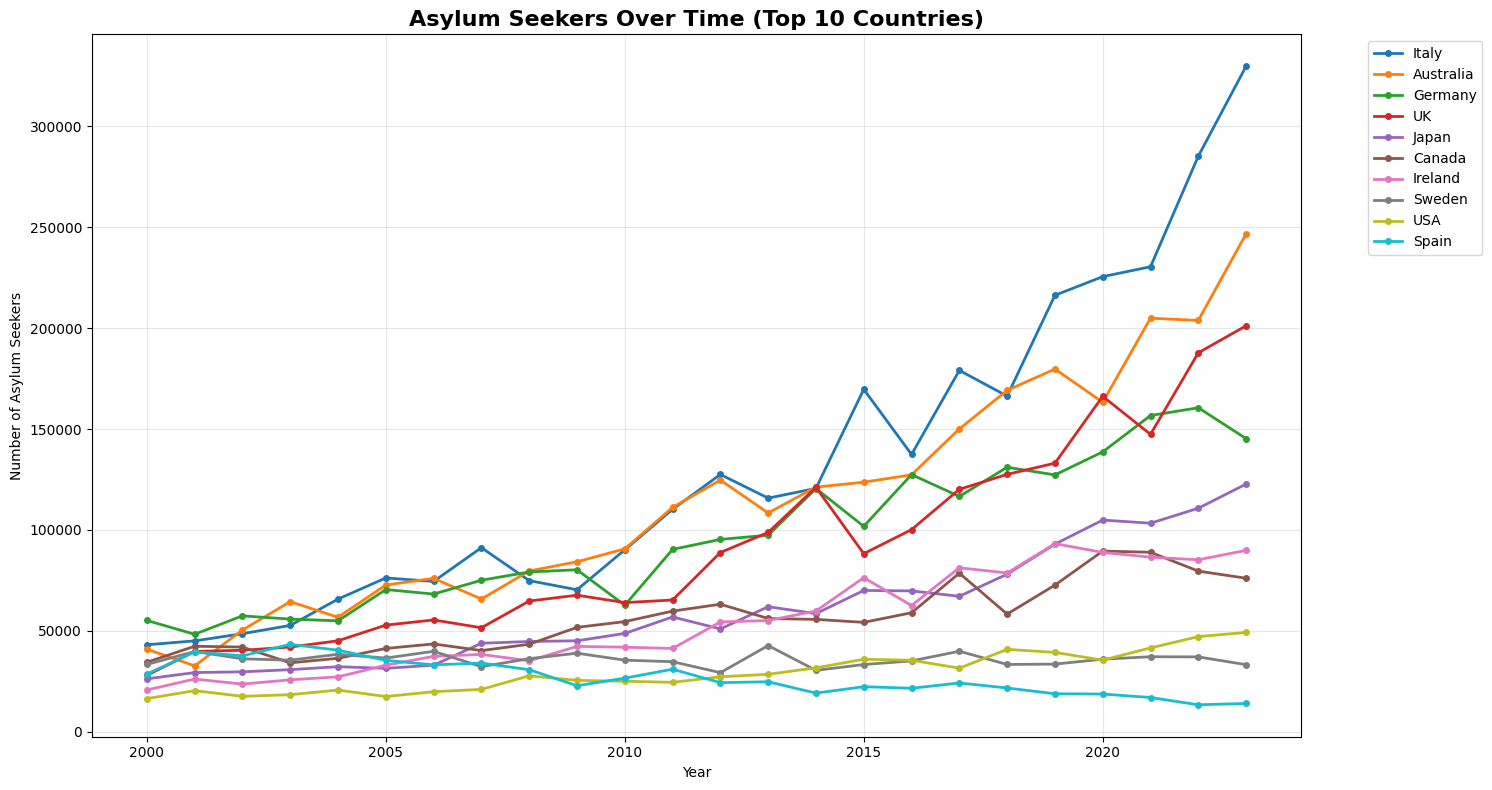

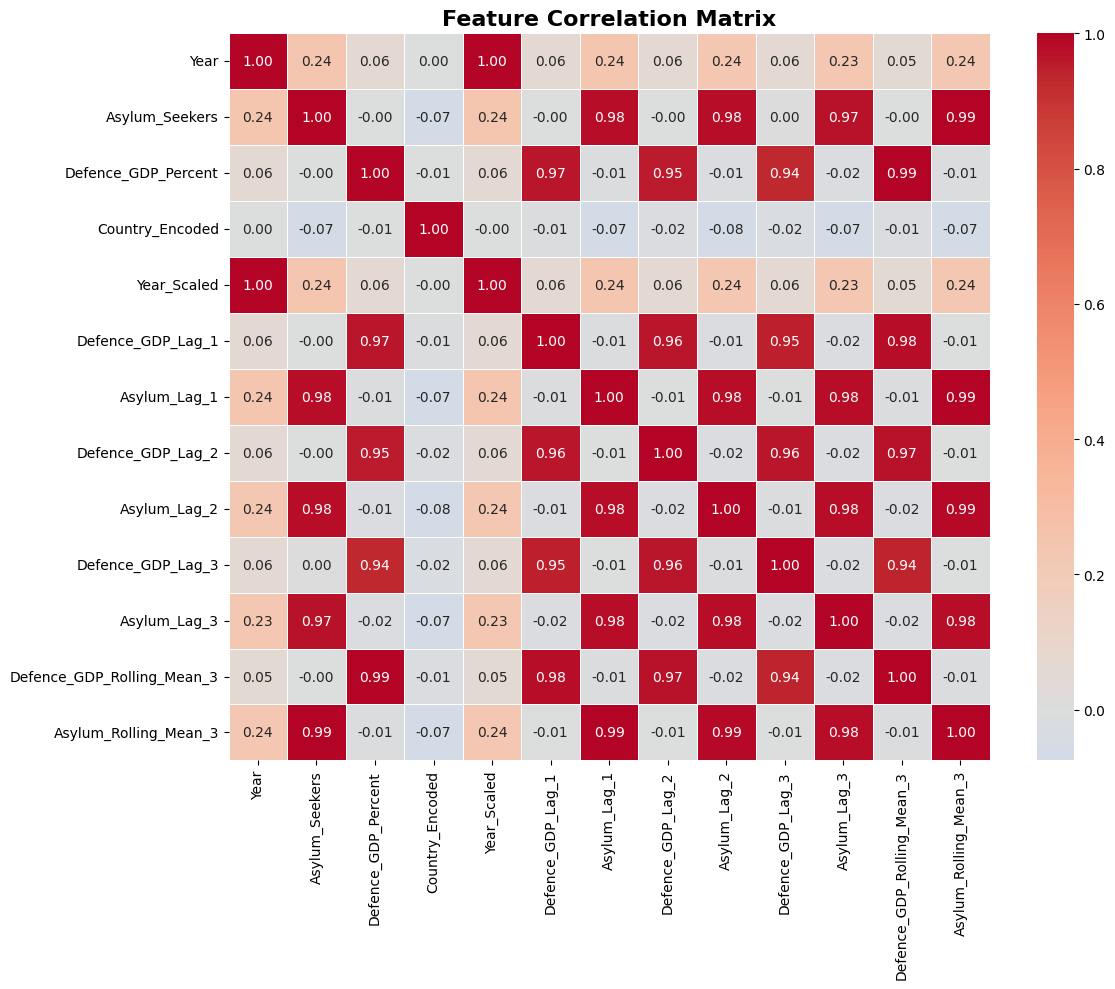


📊 Train-Test Split:
  Training years: 2000 - 2019
  Test years: 2020 - 2023
  Training samples: 400
  Test samples: 80
  Features used: ['Year_Scaled', 'Country_Encoded', 'Defence_GDP_Percent', 'Defence_GDP_Lag_1', 'Defence_GDP_Lag_2', 'Asylum_Lag_1', 'Asylum_Lag_2', 'Defence_GDP_Rolling_Mean_3', 'Asylum_Rolling_Mean_3']

🤖 Training Models...
  Training Random Forest...
  Training XGBoost...
  Training Gradient Boosting...
  Training Linear Regression...
  Training Ridge Regression...
  Training Lasso Regression...
  Training SVR...
  Training Neural Network...

🔍 Feature Importance Analysis:

Random Forest Feature Importance:
                   feature  importance
     Asylum_Rolling_Mean_3    0.954258
              Asylum_Lag_1    0.031348
              Asylum_Lag_2    0.008032
         Defence_GDP_Lag_2    0.001424
               Year_Scaled    0.001301
Defence_GDP_Rolling_Mean_3    0.001022
         Defence_GDP_Lag_1    0.001014
           Country_Encoded    0.000828
       Defenc

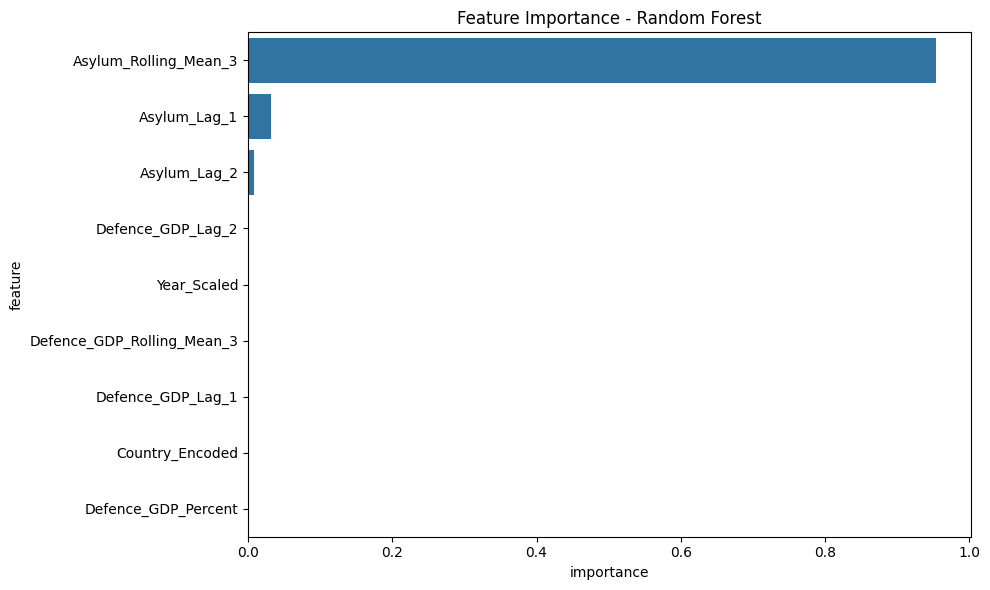


XGBoost Feature Importance:
                   feature  importance
     Asylum_Rolling_Mean_3    0.985072
              Asylum_Lag_2    0.006837
              Asylum_Lag_1    0.003676
         Defence_GDP_Lag_2    0.001343
         Defence_GDP_Lag_1    0.001033
Defence_GDP_Rolling_Mean_3    0.000637
               Year_Scaled    0.000611
           Country_Encoded    0.000528
       Defence_GDP_Percent    0.000263


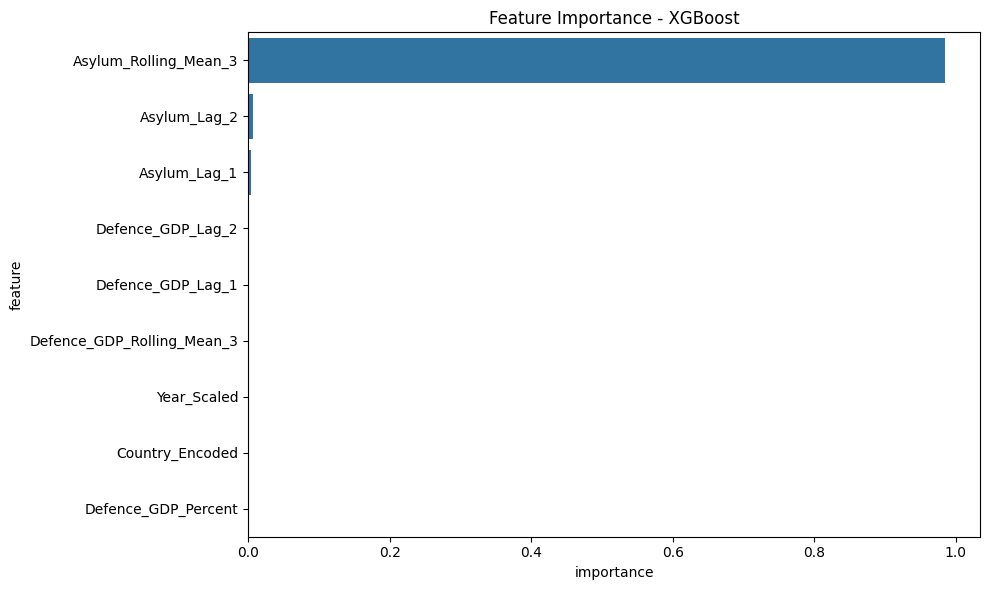


Gradient Boosting Feature Importance:
                   feature  importance
     Asylum_Rolling_Mean_3    0.988951
              Asylum_Lag_2    0.003379
              Asylum_Lag_1    0.003167
         Defence_GDP_Lag_2    0.001302
               Year_Scaled    0.001094
         Defence_GDP_Lag_1    0.000731
Defence_GDP_Rolling_Mean_3    0.000727
       Defence_GDP_Percent    0.000411
           Country_Encoded    0.000239


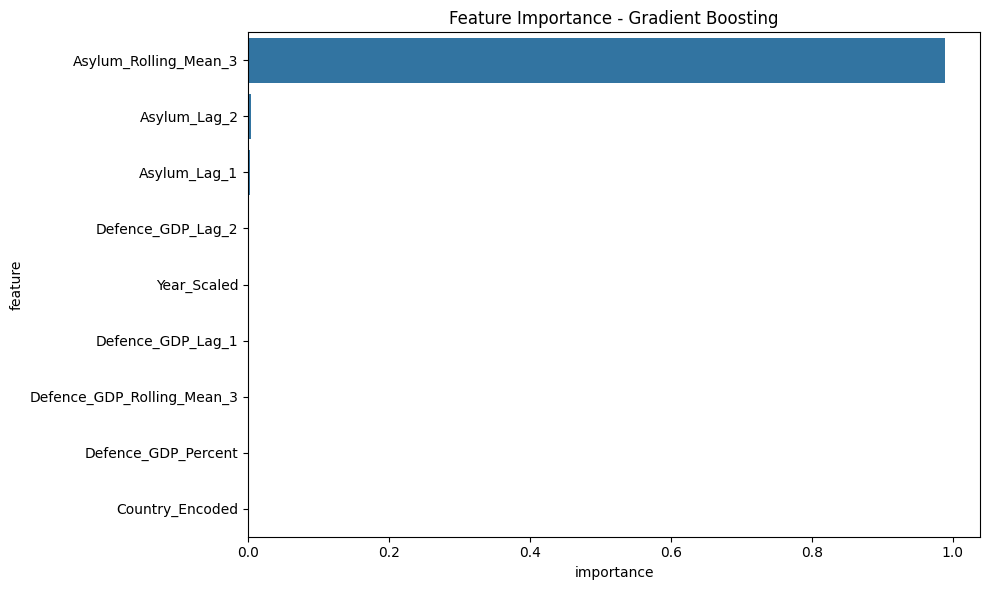


📊 Model Evaluation Results:
--------------------------------------------------------------------------------

Random Forest:
  MAE:  7,685.01
  RMSE: 19,892.34
  R²:   0.9356
  MAPE: 11.72%

XGBoost:
  MAE:  7,340.33
  RMSE: 17,829.44
  R²:   0.9482
  MAPE: 13.48%

Gradient Boosting:
  MAE:  6,590.92
  RMSE: 17,524.31
  R²:   0.9500
  MAPE: 15.99%

Linear Regression:
  MAE:  2,966.71
  RMSE: 4,930.53
  R²:   0.9960
  MAPE: 18.97%

Ridge Regression:
  MAE:  3,416.37
  RMSE: 5,751.93
  R²:   0.9946
  MAPE: 19.98%

Lasso Regression:
  MAE:  2,967.57
  RMSE: 4,932.06
  R²:   0.9960
  MAPE: 18.98%

SVR:
  MAE:  55,962.26
  RMSE: 85,895.08
  R²:   -0.2015
  MAPE: 589.75%

Neural Network:
  MAE:  11,573.44
  RMSE: 16,314.62
  R²:   0.9567
  MAPE: 365.40%


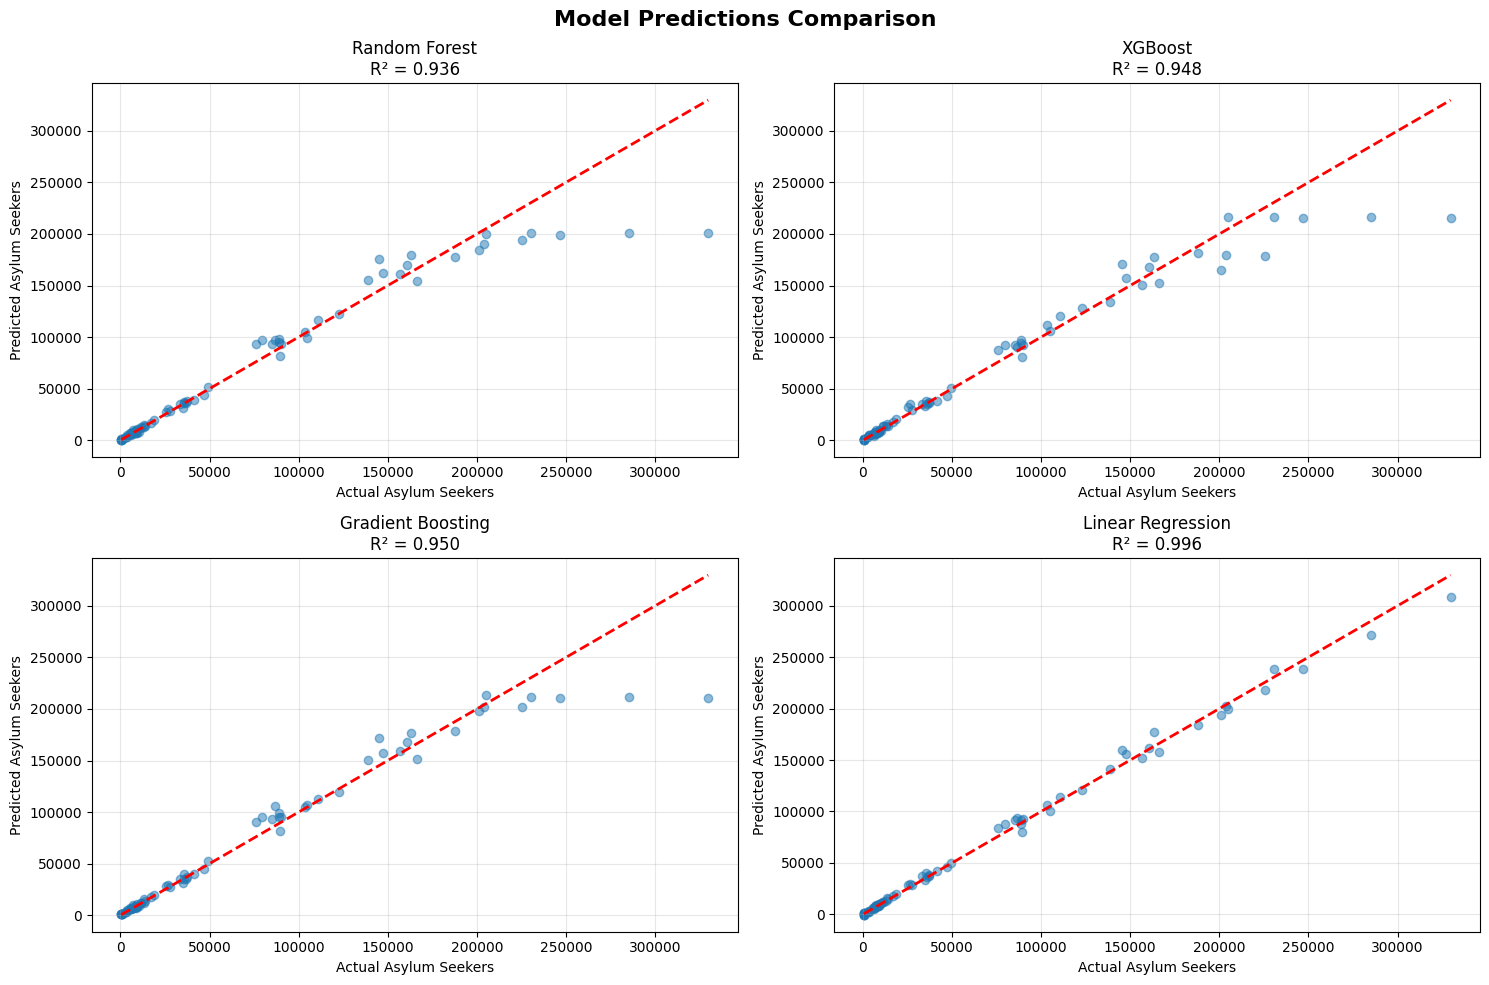

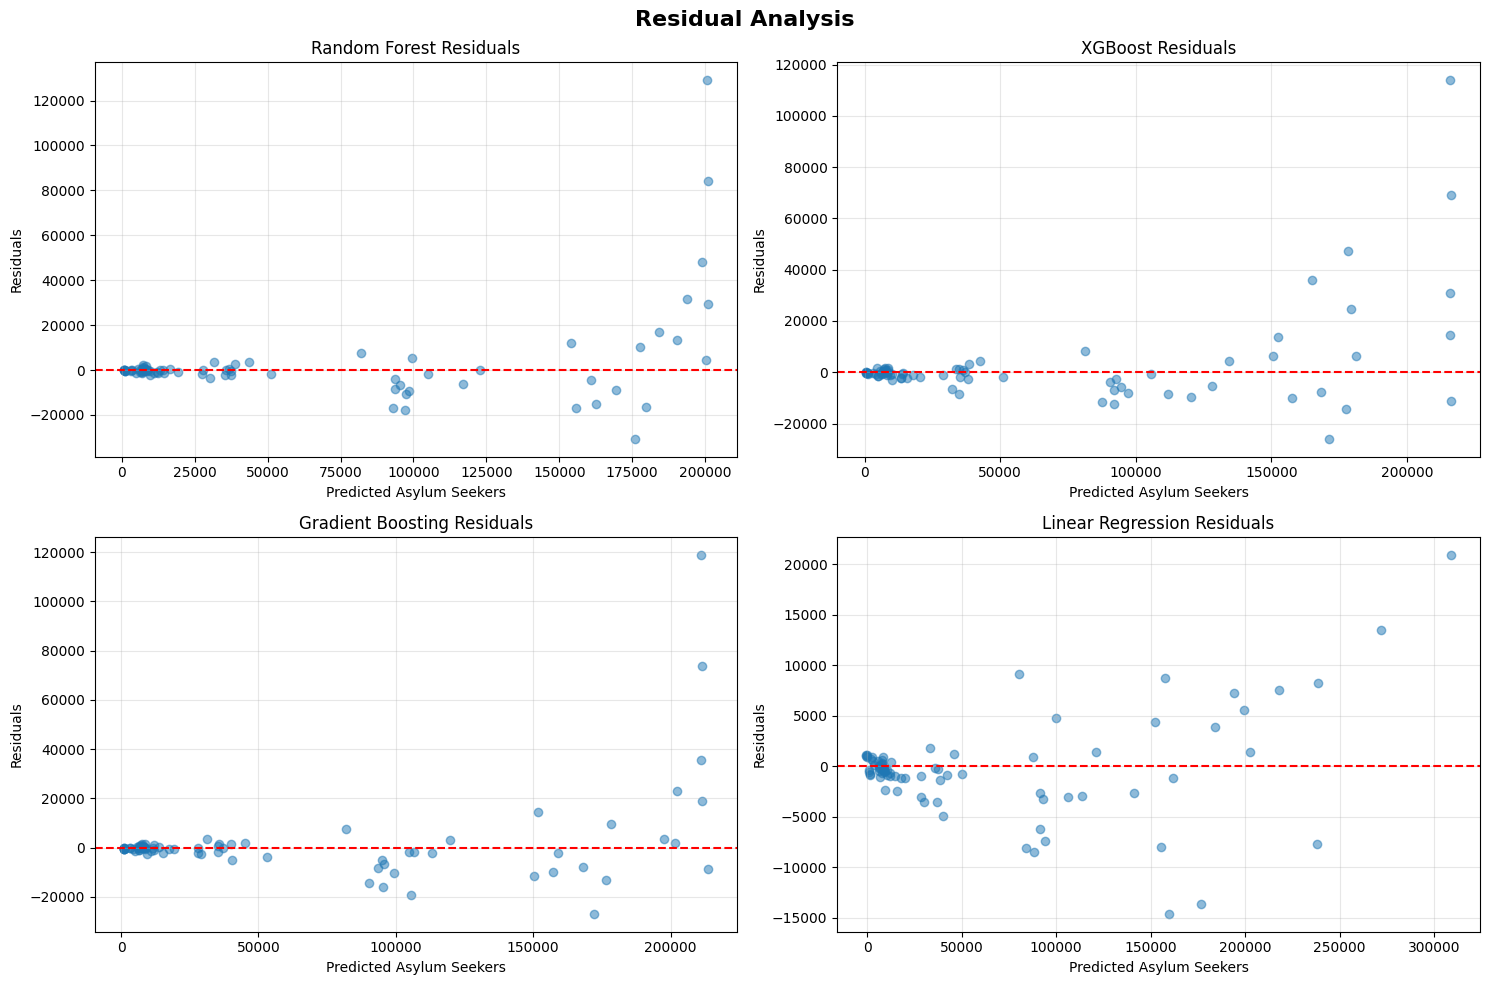


🎯 Detailed Analysis for Countries:

Country: Italy


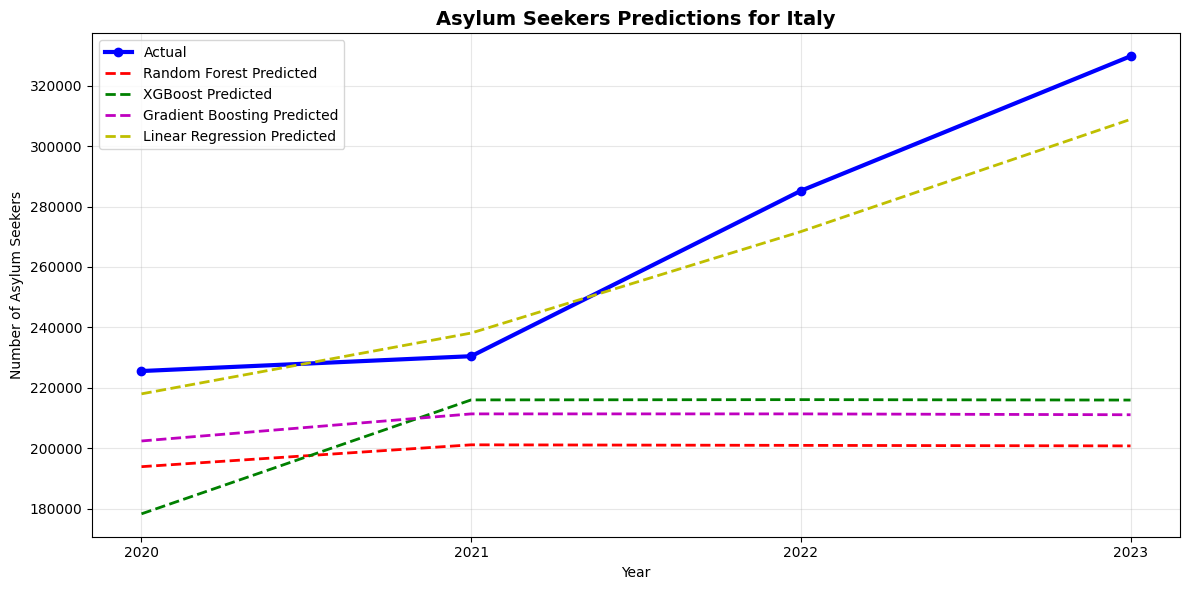


Country: Australia


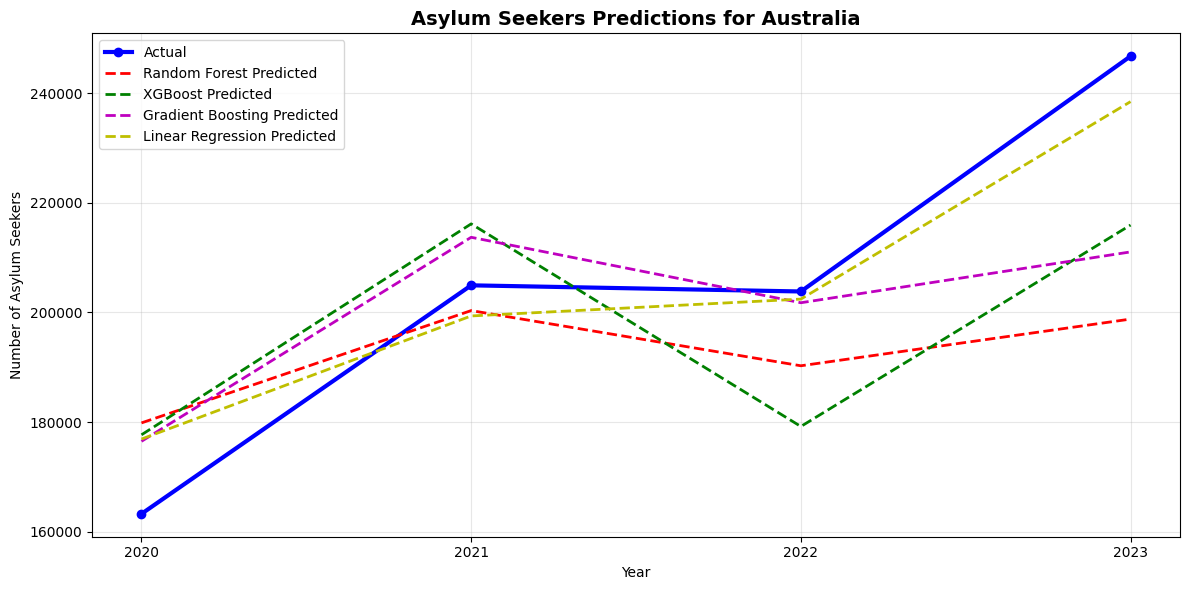


Country: Germany


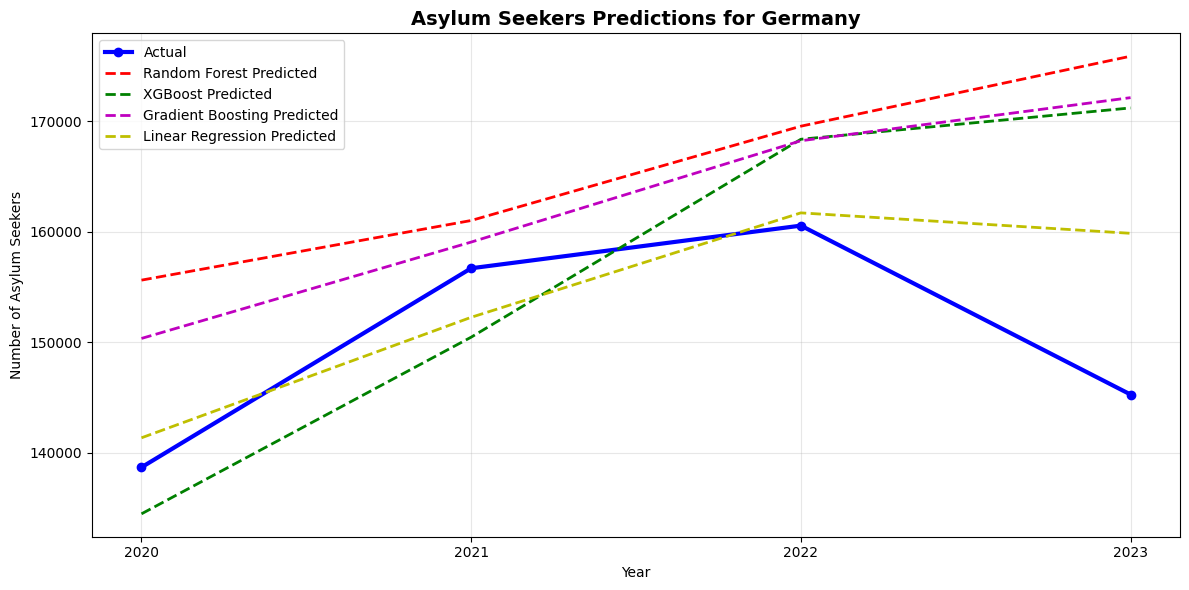


Country: UK


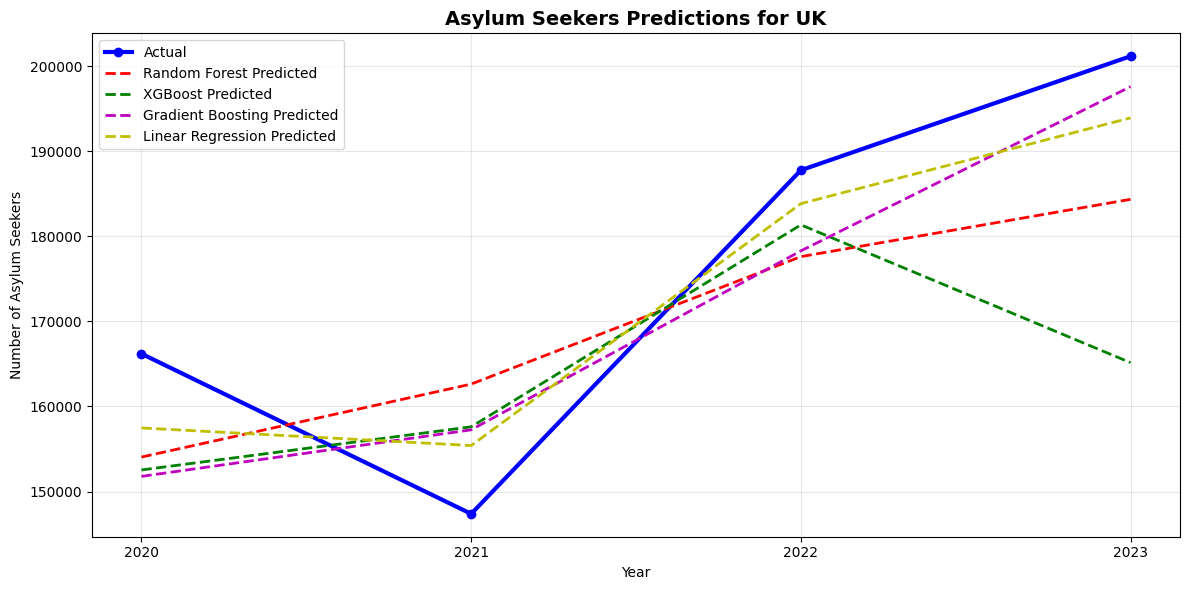


Country: Japan


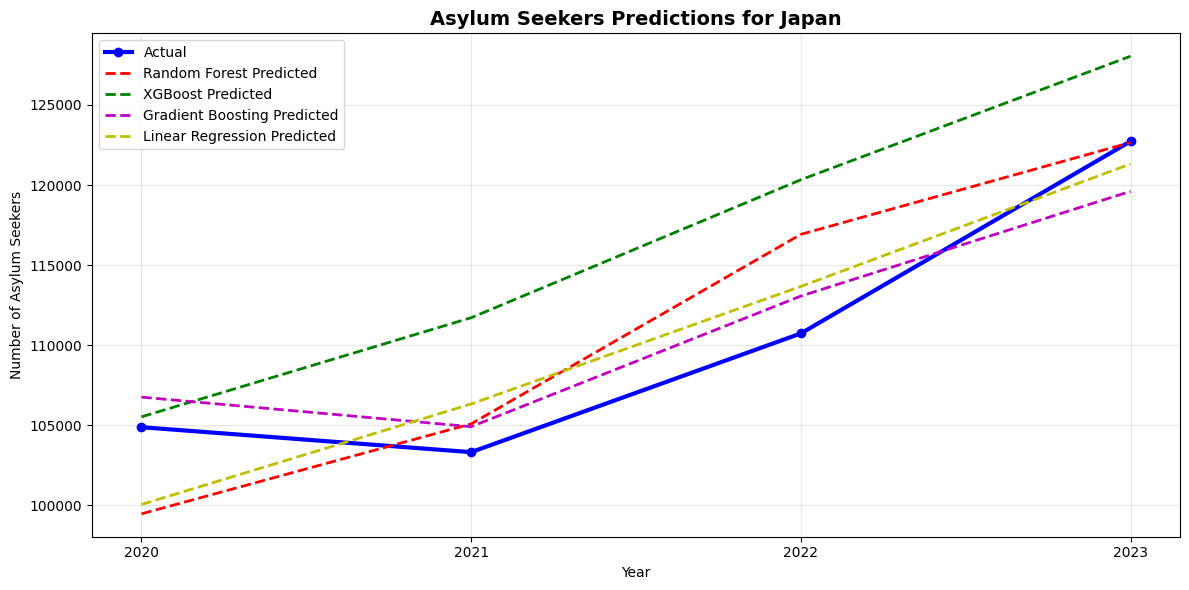


🏆 Best Model Identification:
Best Model: Linear Regression with R² = 0.9960


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================
# LOAD AND PREPARE DATA
# ==========================
def load_and_prepare_data(file_path):
    """
    Load and prepare asylum seekers dataset
    """
    # Load the dataset
    df = pd.read_csv(file_path)

    print("Dataset Info:")
    print(f"Shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    # Check if required columns exist
    required_cols = ['Year', 'Country', 'Defence_GDP_Percent', 'Asylum_Seekers']
    for col in required_cols:
        if col not in df.columns:
            print(f"\n⚠️ Warning: Column '{col}' not found in dataset")
            print(f"Available columns: {df.columns.tolist()}")
            # Try to find similar columns
            similar = [c for c in df.columns if col.lower() in c.lower()]
            if similar:
                print(f"Similar columns found: {similar}")

    return df

# ==========================
# DATA PREPROCESSING
# ==========================
def preprocess_data(df):
    """
    Preprocess the asylum seekers data
    """
    # Create a copy to avoid modifying original
    df_processed = df.copy()

    # 1. Handle missing values
    print("\n📊 Handling missing values...")
    for col in ['Defence_GDP_Percent', 'Asylum_Seekers']:
        if col in df_processed.columns:
            missing_before = df_processed[col].isnull().sum()
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
            missing_after = df_processed[col].isnull().sum()
            print(f"  {col}: {missing_before} → {missing_after} missing values")

    # 2. Encode categorical variables
    print("\n🔧 Encoding categorical variables...")

    # Label encode country
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # 3. Create time-based features
    print("📅 Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()

    # 4. Create lag features for time series
    print("⏰ Creating lag features...")
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # Create lag features for each country separately
    lag_features = []
    for country in df_processed['Country'].unique():
        country_mask = df_processed['Country'] == country
        country_data = df_processed[country_mask].copy()

        # Create lag features
        for lag in [1, 2, 3]:  # 1, 2, and 3 year lags
            country_data[f'Defence_GDP_Lag_{lag}'] = country_data['Defence_GDP_Percent'].shift(lag)
            country_data[f'Asylum_Lag_{lag}'] = country_data['Asylum_Seekers'].shift(lag)
            lag_features.extend([f'Defence_GDP_Lag_{lag}', f'Asylum_Lag_{lag}'])

        # Update the dataframe
        df_processed.loc[country_mask, country_data.columns] = country_data

    # 5. Fill NaN in lag features with median
    for col in lag_features:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 6. Create rolling statistics
    print("📈 Creating rolling statistics...")
    for country in df_processed['Country'].unique():
        country_mask = df_processed['Country'] == country
        country_data = df_processed[country_mask].copy()

        # Rolling mean for defence GDP (3-year window)
        country_data['Defence_GDP_Rolling_Mean_3'] = country_data['Defence_GDP_Percent'].rolling(
            window=3, min_periods=1).mean()

        # Rolling mean for asylum seekers (3-year window)
        country_data['Asylum_Rolling_Mean_3'] = country_data['Asylum_Seekers'].rolling(
            window=3, min_periods=1).mean()

        df_processed.loc[country_mask, country_data.columns] = country_data

    print(f"\n✅ Final dataset shape: {df_processed.shape}")
    print(f"✅ Features created: {df_processed.columns.tolist()}")

    return df_processed, le_country

# ==========================
# MODEL IMPLEMENTATION
# ==========================
class AsylumSeekersPredictor:
    """
    Main class for asylum seekers prediction using multiple models
    """
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.results = {}

    def prepare_features(self, df, target_col='Asylum_Seekers'):
        """
        Prepare features for modeling
        """
        # Select features - you can modify this based on your dataset
        feature_cols = [
            'Year_Scaled',
            'Country_Encoded',
            'Defence_GDP_Percent',
            'Defence_GDP_Lag_1',
            'Defence_GDP_Lag_2',
            'Asylum_Lag_1',
            'Asylum_Lag_2',
            'Defence_GDP_Rolling_Mean_3',
            'Asylum_Rolling_Mean_3'
        ]

        # Only use columns that exist in dataframe
        available_cols = [col for col in feature_cols if col in df.columns]

        X = df[available_cols]
        y = df[target_col] if target_col in df.columns else None

        return X, y, available_cols

    def train_test_split_by_year(self, df, test_years=[2020, 2021, 2022, 2023]):
        """
        Split data by year for time series validation
        """
        train_df = df[~df['Year'].isin(test_years)]
        test_df = df[df['Year'].isin(test_years)]

        X_train, y_train, _ = self.prepare_features(train_df)
        X_test, y_test, feature_cols = self.prepare_features(test_df)

        print(f"\n📊 Train-Test Split:")
        print(f"  Training years: {train_df['Year'].min()} - {train_df['Year'].max()}")
        print(f"  Test years: {test_df['Year'].min()} - {test_df['Year'].max()}")
        print(f"  Training samples: {len(train_df)}")
        print(f"  Test samples: {len(test_df)}")
        print(f"  Features used: {feature_cols}")

        return X_train, X_test, y_train, y_test, feature_cols

    def train_models(self, X_train, y_train, feature_cols):
        """
        Train multiple models for comparison
        """
        from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
        from sklearn.linear_model import LinearRegression, Ridge, Lasso
        from sklearn.svm import SVR
        from xgboost import XGBRegressor
        from sklearn.neural_network import MLPRegressor

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        self.scalers['standard'] = scaler

        # Define models
        models = {
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0, random_state=42),
            'Lasso Regression': Lasso(alpha=0.1, random_state=42),
            'SVR': SVR(kernel='rbf'),
            'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
        }

        print("\n🤖 Training Models...")
        for name, model in models.items():
            print(f"  Training {name}...")
            model.fit(X_train_scaled, y_train)
            self.models[name] = model

        # Feature importance for tree-based models
        self.calculate_feature_importance(X_train.columns)

        return models

    def calculate_feature_importance(self, feature_names):
        """
        Calculate and display feature importance
        """
        print("\n🔍 Feature Importance Analysis:")

        for name, model in self.models.items():
            if hasattr(model, 'feature_importances_'):
                importance = pd.DataFrame({
                    'feature': feature_names,
                    'importance': model.feature_importances_
                }).sort_values('importance', ascending=False)

                print(f"\n{name} Feature Importance:")
                print(importance.head(10).to_string(index=False))

                # Plot feature importance
                plt.figure(figsize=(10, 6))
                sns.barplot(x='importance', y='feature', data=importance.head(15))
                plt.title(f'Feature Importance - {name}')
                plt.tight_layout()
                plt.show()

    def evaluate_models(self, X_test, y_test):
        """
        Evaluate all trained models
        """
        results = {}

        # Scale test features
        X_test_scaled = self.scalers['standard'].transform(X_test)

        print("\n📊 Model Evaluation Results:")
        print("-" * 80)

        for name, model in self.models.items():
            y_pred = model.predict(X_test_scaled)

            # Calculate metrics
            metrics = {
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'R2': r2_score(y_test, y_pred),
                'MAPE': self.calculate_mape(y_test, y_pred)
            }

            results[name] = {
                'predictions': y_pred,
                'metrics': metrics
            }

            print(f"\n{name}:")
            print(f"  MAE:  {metrics['MAE']:,.2f}")
            print(f"  RMSE: {metrics['RMSE']:,.2f}")
            print(f"  R²:   {metrics['R2']:.4f}")
            print(f"  MAPE: {metrics['MAPE']:.2f}%")

        self.results = results
        return results

    def calculate_mape(self, y_true, y_pred):
        """
        Calculate Mean Absolute Percentage Error
        """
        return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    def plot_predictions(self, y_test, predictions_dict, model_names, title="Model Predictions Comparison"):
        """
        Plot predictions vs actual values
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for idx, (model_name, ax) in enumerate(zip(model_names[:4], axes)):
            if model_name in predictions_dict:
                y_pred = predictions_dict[model_name]

                ax.scatter(y_test, y_pred, alpha=0.5)
                ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
                ax.set_xlabel('Actual Asylum Seekers')
                ax.set_ylabel('Predicted Asylum Seekers')
                ax.set_title(f'{model_name}\nR² = {self.results[model_name]["metrics"]["R2"]:.3f}')
                ax.grid(True, alpha=0.3)

        plt.suptitle(title, fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_residuals(self, y_test, predictions_dict, model_names):
        """
        Plot residuals for model diagnostics
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()

        for idx, (model_name, ax) in enumerate(zip(model_names[:4], axes)):
            if model_name in predictions_dict:
                y_pred = predictions_dict[model_name]
                residuals = y_test - y_pred

                ax.scatter(y_pred, residuals, alpha=0.5)
                ax.axhline(y=0, color='r', linestyle='--')
                ax.set_xlabel('Predicted Asylum Seekers')
                ax.set_ylabel('Residuals')
                ax.set_title(f'{model_name} Residuals')
                ax.grid(True, alpha=0.3)

        plt.suptitle('Residual Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def analyze_country_predictions(self, df, test_years, country_name=None):
        """
        Analyze predictions for specific countries
        """
        if country_name:
            countries = [country_name]
        else:
            # Get top 5 countries by average asylum seekers
            countries = df.groupby('Country')['Asylum_Seekers'].mean().nlargest(5).index.tolist()

        print(f"\n🎯 Detailed Analysis for Countries:")

        for country in countries:
            country_df = df[df['Country'] == country].copy()
            test_country = country_df[country_df['Year'].isin(test_years)]

            if len(test_country) == 0:
                continue

            print(f"\n{'='*60}")
            print(f"Country: {country}")
            print(f"{'='*60}")

            X_country, y_country, feature_cols = self.prepare_features(test_country)
            X_country_scaled = self.scalers['standard'].transform(X_country)

            plt.figure(figsize=(12, 6))

            # Plot actual values
            years = test_country['Year'].values
            plt.plot(years, y_country.values, 'b-', label='Actual', linewidth=3, marker='o')

            # Plot predictions from each model
            colors = ['r--', 'g--', 'm--', 'y--']
            for idx, (model_name, color) in enumerate(zip(list(self.models.keys())[:4], colors)):
                y_pred = self.models[model_name].predict(X_country_scaled)
                plt.plot(years, y_pred, color, label=f'{model_name} Predicted', linewidth=2)

            plt.title(f'Asylum Seekers Predictions for {country}', fontsize=14, fontweight='bold')
            plt.xlabel('Year')
            plt.ylabel('Number of Asylum Seekers')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(years)
            plt.tight_layout()
            plt.show()

# ==========================
# TIME SERIES APPROACH (LSTM/GRU)
# ==========================
class TimeSeriesPredictor:
    """
    LSTM/GRU based time series predictor for asylum seekers
    """
    def __init__(self):
        self.model = None
        self.scaler = None

    def create_sequences(self, data, sequence_length=3):
        """
        Create sequences for time series prediction
        """
        sequences = []
        targets = []

        for i in range(len(data) - sequence_length):
            seq = data[i:i+sequence_length]
            target = data[i+sequence_length]
            sequences.append(seq)
            targets.append(target)

        return np.array(sequences), np.array(targets)

    def prepare_time_series_data(self, df, country, sequence_length=3):
        """
        Prepare time series data for a specific country
        """
        country_df = df[df['Country'] == country].sort_values('Year')

        # Select features for time series
        features = ['Defence_GDP_Percent', 'Asylum_Seekers']
        data = country_df[features].values

        # Scale the data
        from sklearn.preprocessing import MinMaxScaler
        self.scaler = MinMaxScaler()
        data_scaled = self.scaler.fit_transform(data)

        # Create sequences
        X, y = self.create_sequences(data_scaled, sequence_length)

        # Split into train/test (last 20% for testing)
        split_idx = int(len(X) * 0.8)
        X_train, X_test = X[:split_idx], X[split_idx:]
        y_train, y_test = y[:split_idx], y[split_idx:]

        # Reshape for LSTM [samples, timesteps, features]
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], len(features)))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], len(features)))

        return X_train, X_test, y_train, y_test

    def build_lstm_model(self, input_shape):
        """
        Build LSTM model
        """
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout
        from tensorflow.keras.optimizers import Adam

        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(50, return_sequences=False),
            Dropout(0.2),
            Dense(25, activation='relu'),
            Dense(1)  # Output: asylum seekers prediction
        ])

        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        return model

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("🚀 ASYLUM SEEKERS PREDICTION MODEL")
    print("="*60)

    # 1. Load data
    # Replace with your actual file path
    file_path = '/content/drive/MyDrive/Colab Notebooks/asylum_dataset.csv'

    try:
        df = load_and_prepare_data(file_path)
    except FileNotFoundError:
        print(f"\n❌ File not found: {file_path}")
        print("\n📝 Creating sample dataset for demonstration...")
        df = create_sample_dataset()

    # 2. Preprocess data
    df_processed, le_country = preprocess_data(df)

    # Display sample of processed data
    print("\n📋 Sample of Processed Data:")
    print(df_processed.head())

    # 3. Exploratory Data Analysis
    print("\n🔍 Exploratory Data Analysis:")

    # Plot asylum seekers over time
    plt.figure(figsize=(15, 8))

    # Top 10 countries by average asylum seekers
    top_countries = df_processed.groupby('Country')['Asylum_Seekers'].mean().nlargest(10).index

    for country in top_countries:
        country_data = df_processed[df_processed['Country'] == country]
        plt.plot(country_data['Year'], country_data['Asylum_Seekers'],
                label=country, linewidth=2, marker='o', markersize=4)

    plt.title('Asylum Seekers Over Time (Top 10 Countries)', fontsize=16, fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Number of Asylum Seekers')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Correlation analysis
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
    correlation_matrix = df_processed[numeric_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', linewidths=0.5)
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 4. Train and evaluate models
    predictor = AsylumSeekersPredictor()

    # Split data (test on recent years)
    test_years = [2020, 2021, 2022, 2023]
    X_train, X_test, y_train, y_test, feature_cols = predictor.train_test_split_by_year(
        df_processed, test_years
    )

    # Train models
    models = predictor.train_models(X_train, y_train, feature_cols)

    # Evaluate models
    results = predictor.evaluate_models(X_test, y_test)

    # 5. Visualizations
    predictions_dict = {name: results[name]['predictions']
                       for name in results.keys()}

    # Plot predictions vs actual
    predictor.plot_predictions(y_test, predictions_dict, list(models.keys()))

    # Plot residuals
    predictor.plot_residuals(y_test, predictions_dict, list(models.keys()))

    # 6. Country-specific analysis
    predictor.analyze_country_predictions(df_processed, test_years)

    # 7. Best model analysis
    print("\n🏆 Best Model Identification:")
    best_model = max(results.items(), key=lambda x: x[1]['metrics']['R2'])
    print(f"Best Model: {best_model[0]} with R² = {best_model[1]['metrics']['R2']:.4f}")

    # 8. Feature importance from best model
    if hasattr(predictor.models[best_model[0]], 'feature_importances_'):
        importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': predictor.models[best_model[0]].feature_importances_
        }).sort_values('importance', ascending=False)

        print("\n📊 Best Model Feature Importance:")
        print(importance.to_string(index=False))

    return predictor, df_processed, results

# ==========================
# SAMPLE DATASET CREATION
# ==========================
def create_sample_dataset():
    """
    Create a sample dataset if actual file is not available
    """
    np.random.seed(42)

    # Create sample data for 20 countries over 20 years
    countries = ['USA', 'Germany', 'France', 'UK', 'Canada', 'Australia',
                'Japan', 'Italy', 'Spain', 'Netherlands', 'Sweden', 'Norway',
                'Denmark', 'Switzerland', 'Austria', 'Belgium', 'Portugal',
                'Greece', 'Ireland', 'Finland']

    years = list(range(2000, 2024))

    data = []
    for country in countries:
        # Base values for each country
        base_asylum = np.random.randint(1000, 50000)
        base_defense = np.random.uniform(1.0, 3.0)

        # Trend and noise
        asylum_trend = np.random.uniform(-0.1, 0.1)
        defense_trend = np.random.uniform(-0.05, 0.05)

        for year in years:
            years_passed = year - 2000

            # Generate asylum seekers with trend and noise
            asylum = base_asylum * (1 + asylum_trend) ** years_passed
            asylum += np.random.normal(0, asylum * 0.1)  # Add noise

            # Generate defense GDP % with trend and noise
            defense = base_defense * (1 + defense_trend) ** years_passed
            defense += np.random.normal(0, defense * 0.05)  # Add noise

            # Ensure realistic ranges
            asylum = max(100, asylum)
            defense = max(0.5, min(5.0, defense))

            data.append({
                'Year': year,
                'Country': country,
                'Asylum_Seekers': int(asylum),
                'Defence_GDP_Percent': round(defense, 2)
            })

    df = pd.DataFrame(data)

    # Add some missing values for realism
    mask = np.random.random(len(df)) < 0.05
    df.loc[mask, 'Defence_GDP_Percent'] = np.nan

    print("\n✅ Sample dataset created with:")
    print(f"   Countries: {len(countries)}")
    print(f"   Years: {len(years)}")
    print(f"   Total records: {len(df)}")

    return df

# ==========================
# RUN THE MODEL
# ==========================
if __name__ == "__main__":
    predictor, df_processed, results = main()

📁 LOADING DATASET...
✅ Dataset loaded: (155, 27)
Columns: 27 columns

First 20 columns:
  1. Country
  2. Year
  3. D_Expenditure_GDP
  4. Conflict_Intensity
  5. Health_Expenditure_(% of GDP)
  6. Education_Expenditure_(% of GDP)
  7. Environmental impact (CO2e/capita)
  8. PM2.5_air_pollution,_mean_annual_exposure_(micrograms_per_cubic_meter)
  9. Refugees
  10. Asylum Seekers
  11. Total number of deaths
  12. Population
  13. GDP_Growth_Annual
  14. GDP_PerCapita_Growth_Annual
  15. GDP_Current_USDollars
  16. Inflation_Annual
  17. Unemployment_Total_of_TLF
  18. Unemployment_Male_of_TMF
  19. Unemployment_Female_of_TFF
  20. Unnamed: 19

🔧 PREPARING FEATURES...
   Handling missing values...
   Encoding categorical variables...
   Creating time-based features...
   Creating lag features...
   Creating rolling statistics...
   Creating interaction features...
✅ Final dataset shape: (155, 51)
✅ Total features created: 51
🎯 COMPREHENSIVE ASYLUM PREDICTOR WITH COUNTRY-WISE ANALYSIS

📋

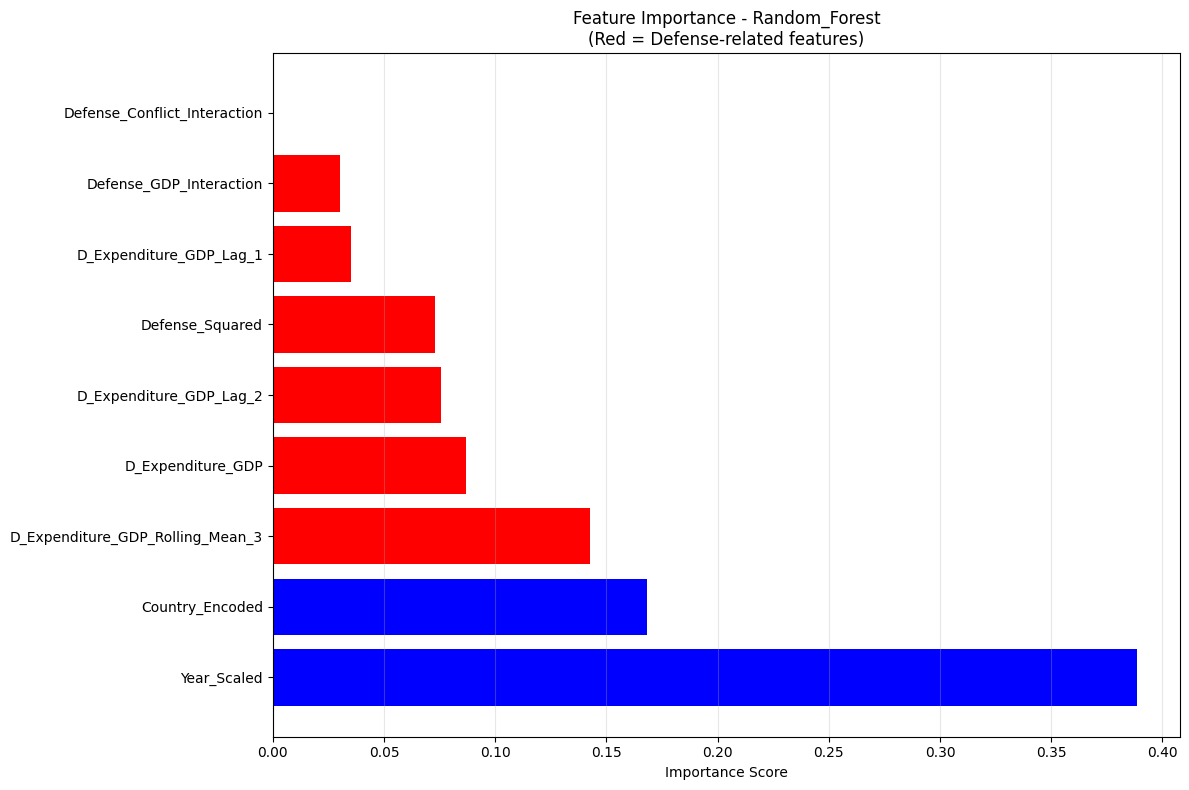


XGBoost - Top 10 Features:
                         Feature  Importance
D_Expenditure_GDP_Rolling_Mean_3    0.552918
                     Year_Scaled    0.253033
                 Country_Encoded    0.126797
               D_Expenditure_GDP    0.048140
         D_Expenditure_GDP_Lag_2    0.012796
         Defense_GDP_Interaction    0.003967
         D_Expenditure_GDP_Lag_1    0.002349
                 Defense_Squared    0.000000
    Defense_Conflict_Interaction    0.000000
  Defense-related features in top 10: 7


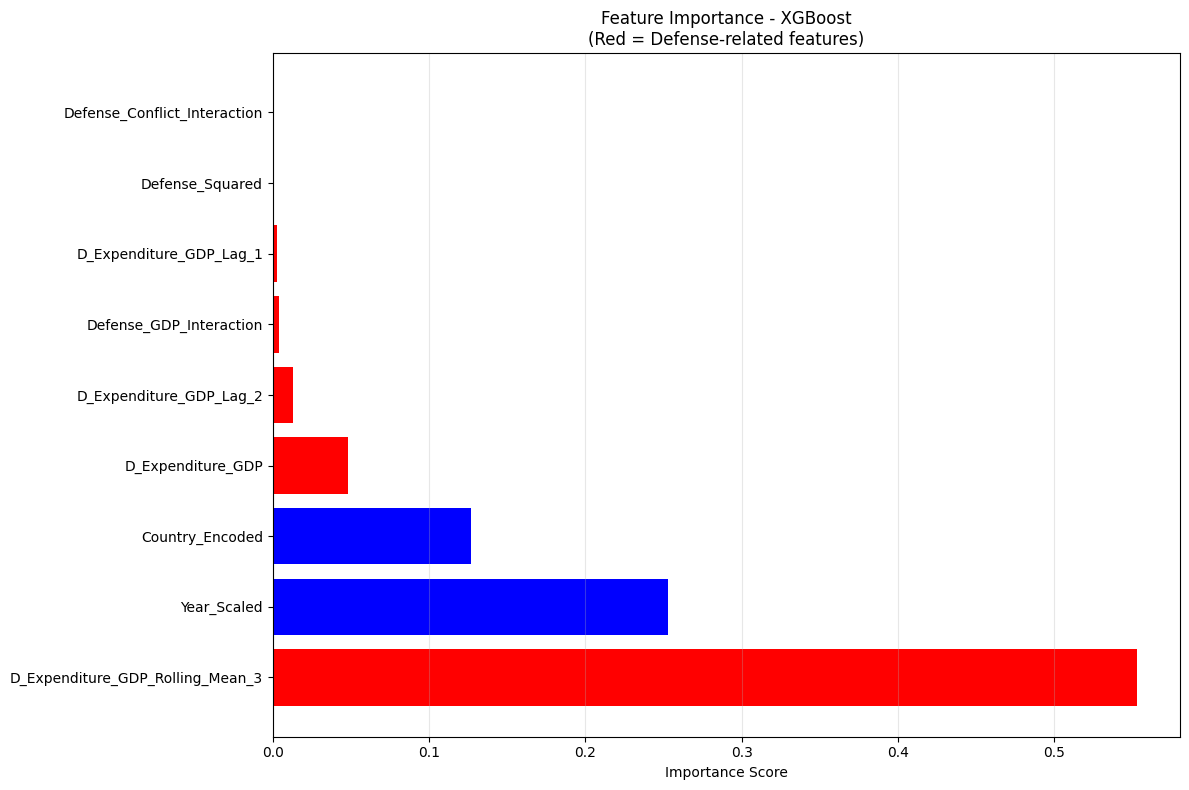


📊 COUNTRY-WISE MODEL EVALUATION - Defense_Only

Random_Forest:
----------------------------------------
  Overall R²:  0.5377
  Overall MAE: 24,066.59
  Overall RMSE: 39,005.97
  Overall MAPE: 636.56%

XGBoost:
----------------------------------------
  Overall R²:  0.7635
  Overall MAE: 13,334.03
  Overall RMSE: 27,900.52
  Overall MAPE: 49.42%

COUNTRY-WISE PERFORMANCE SUMMARY - Defense_Only

Random_Forest:
  Top 3 countries by R²:
    1. RUS: R² = -1.6296
    2. CHN: R² = -5.2806
    3. GBR: R² = -427.7042
  Bottom 3 countries by R²:
    1. GBR: R² = -427.7042
    2. USA: R² = -442.2785
    3. FRA: R² = -1312.0582

XGBoost:
  Top 3 countries by R²:
    1. FRA: R² = -0.6141
    2. GBR: R² = -0.8398
    3. RUS: R² = -0.8749
  Bottom 3 countries by R²:
    1. RUS: R² = -0.8749
    2. CHN: R² = -1.2915
    3. USA: R² = -264.4927

🏆 BEST MODEL FOR EACH COUNTRY:
  CHN: XGBoost (R² = -1.2915)
  FRA: XGBoost (R² = -0.6141)
  GBR: XGBoost (R² = -0.8398)
  RUS: XGBoost (R² = -0.8749)
  USA: 

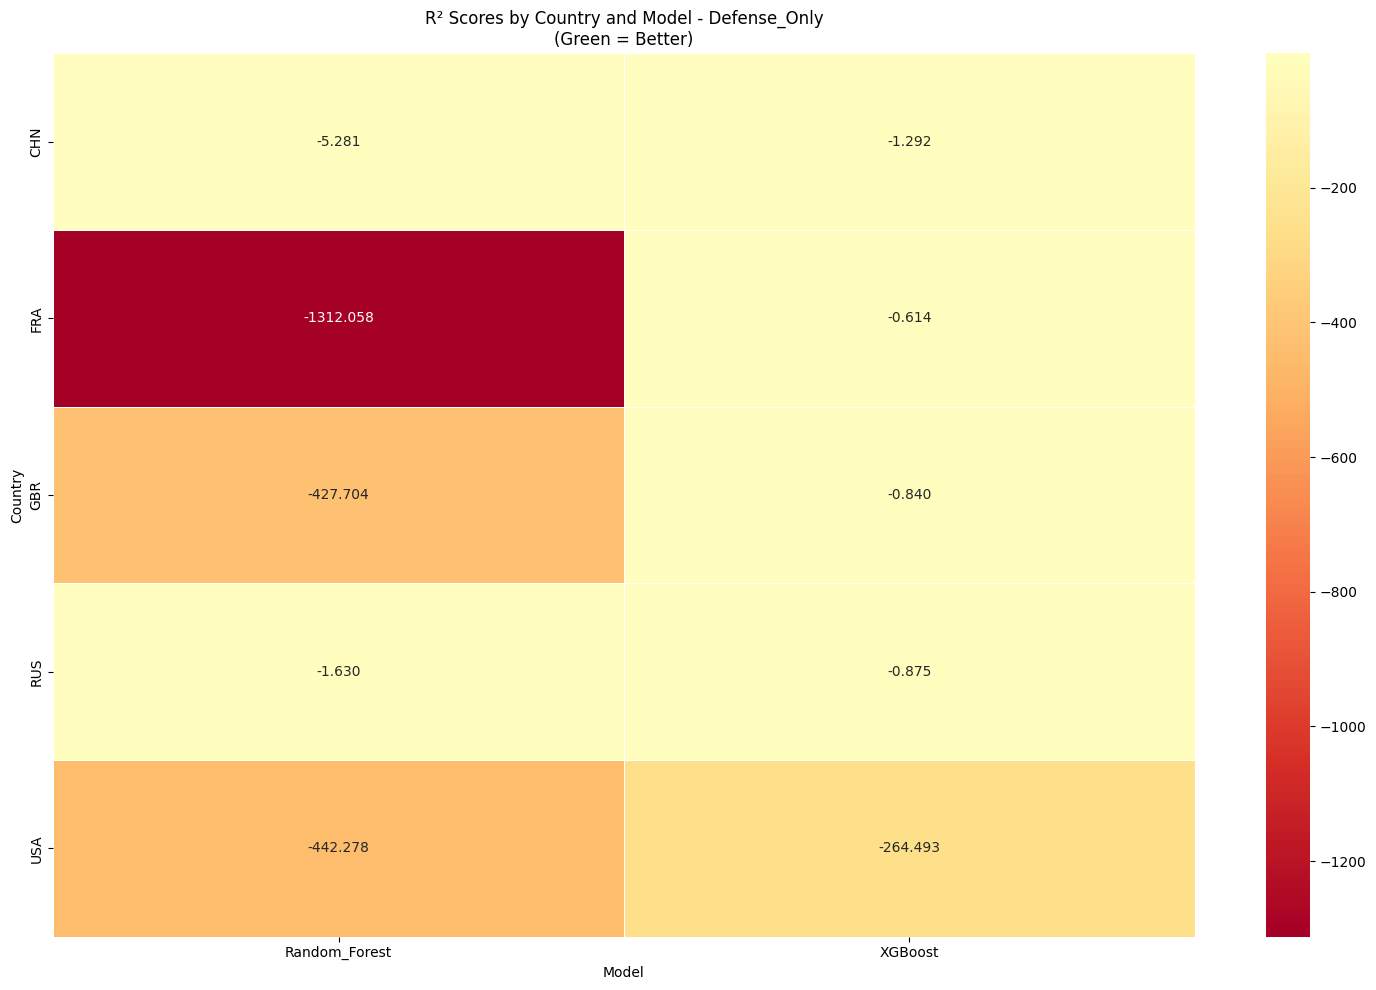

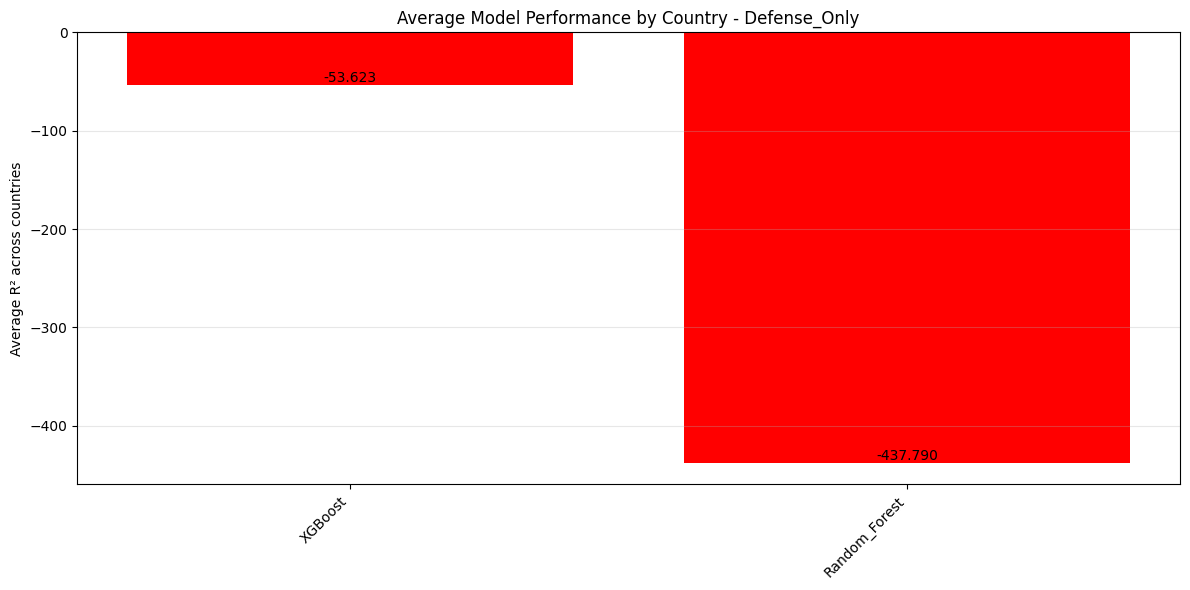


📈 Note: For defense expenditure impact analysis, additional data processing needed.

################################################################################
ANALYZING FEATURE SET: Defense_Economic
################################################################################
  Training samples: 130
  Test samples: 25
  Test countries: 5

🤖 TRAINING MODELS...
  Training Linear_Regression...
    Error training Linear_Regression: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: http

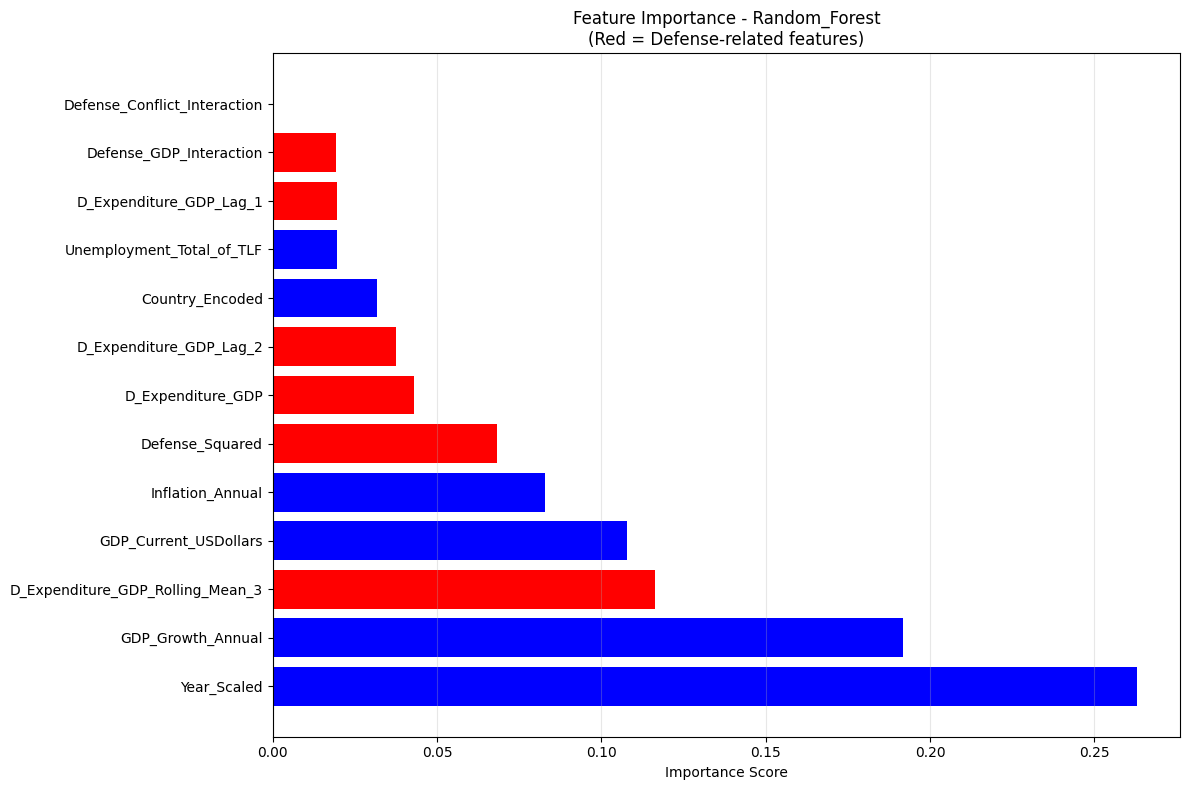


XGBoost - Top 10 Features:
                         Feature  Importance
D_Expenditure_GDP_Rolling_Mean_3    0.641142
                     Year_Scaled    0.146065
                Inflation_Annual    0.070495
                 Country_Encoded    0.069667
         D_Expenditure_GDP_Lag_2    0.050793
               GDP_Growth_Annual    0.009769
       Unemployment_Total_of_TLF    0.003115
         Defense_GDP_Interaction    0.003110
               D_Expenditure_GDP    0.003034
         D_Expenditure_GDP_Lag_1    0.001516
  Defense-related features in top 10: 5


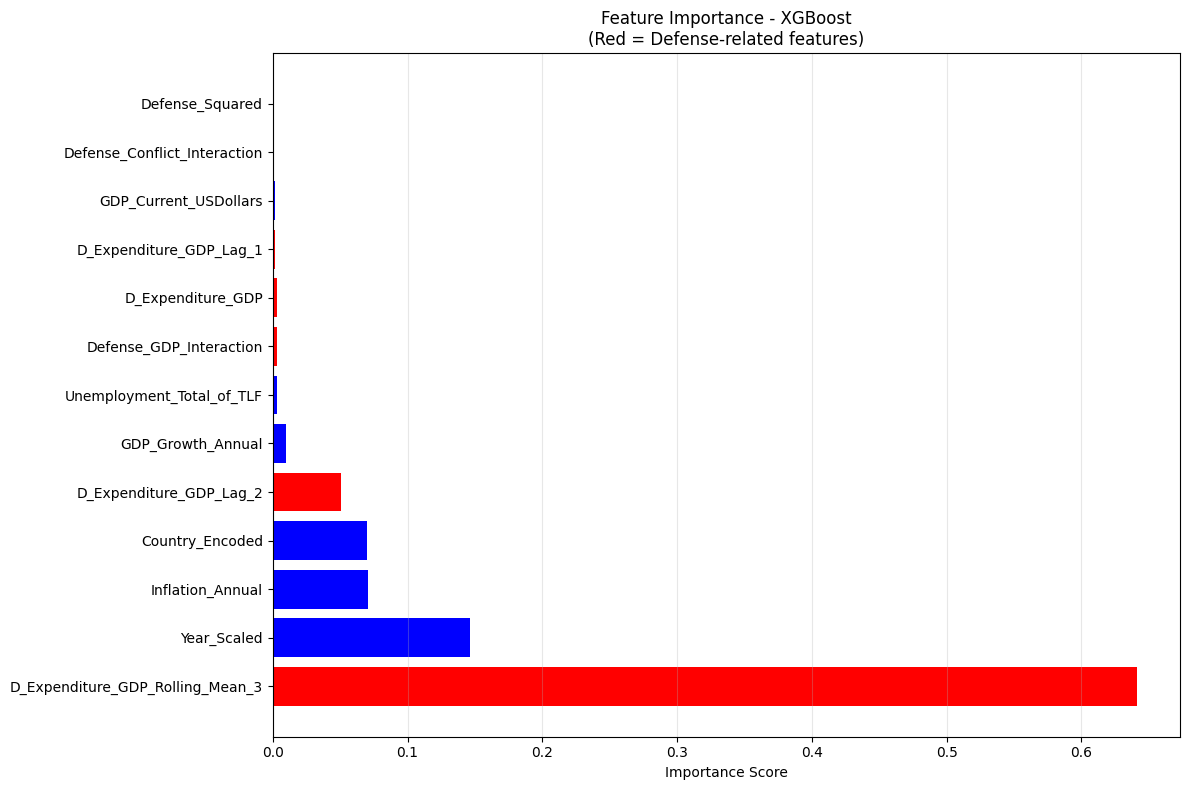


📊 COUNTRY-WISE MODEL EVALUATION - Defense_Economic

Random_Forest:
----------------------------------------
  Overall R²:  0.3893
  Overall MAE: 33,833.81
  Overall RMSE: 44,828.77
  Overall MAPE: 2067.75%

XGBoost:
----------------------------------------
  Overall R²:  0.5678
  Overall MAE: 28,676.62
  Overall RMSE: 37,714.84
  Overall MAPE: 2112.97%

COUNTRY-WISE PERFORMANCE SUMMARY - Defense_Economic

Random_Forest:
  Top 3 countries by R²:
    1. RUS: R² = -1.6307
    2. CHN: R² = -7.2669
    3. USA: R² = -4922.5576
  Bottom 3 countries by R²:
    1. USA: R² = -4922.5576
    2. GBR: R² = -14057.1286
    3. FRA: R² = -14304.1364

XGBoost:
  Top 3 countries by R²:
    1. RUS: R² = -0.8854
    2. CHN: R² = -2.3221
    3. USA: R² = -12380.0537
  Bottom 3 countries by R²:
    1. USA: R² = -12380.0537
    2. GBR: R² = -26745.0645
    3. FRA: R² = -29738.0859

🏆 BEST MODEL FOR EACH COUNTRY:
  CHN: XGBoost (R² = -2.3221)
  FRA: Random_Forest (R² = -14304.1364)
  GBR: Random_Forest (R² = 

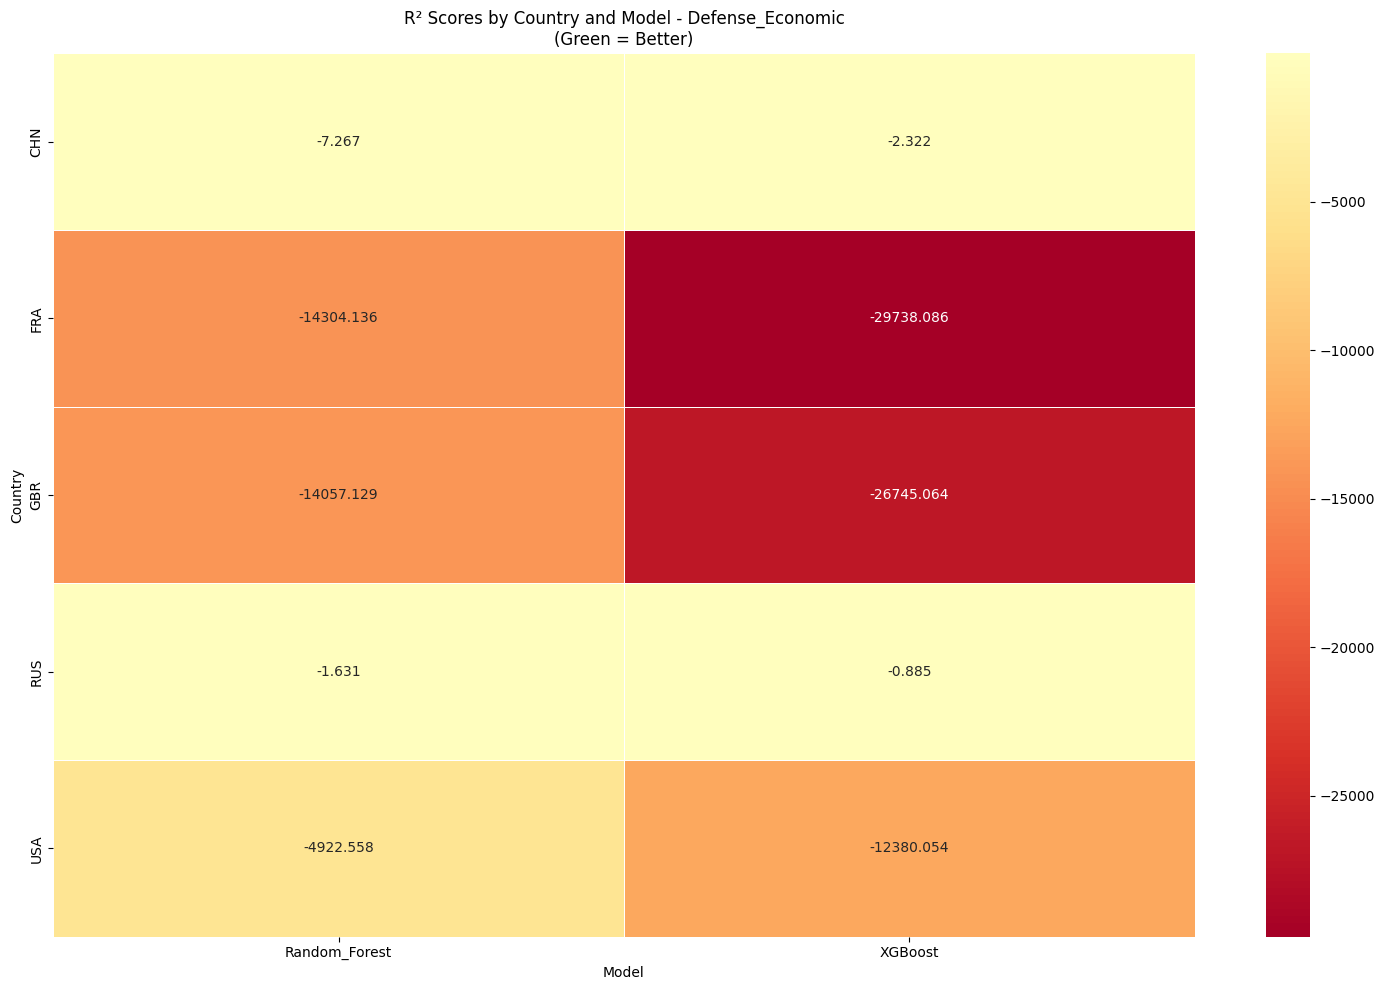

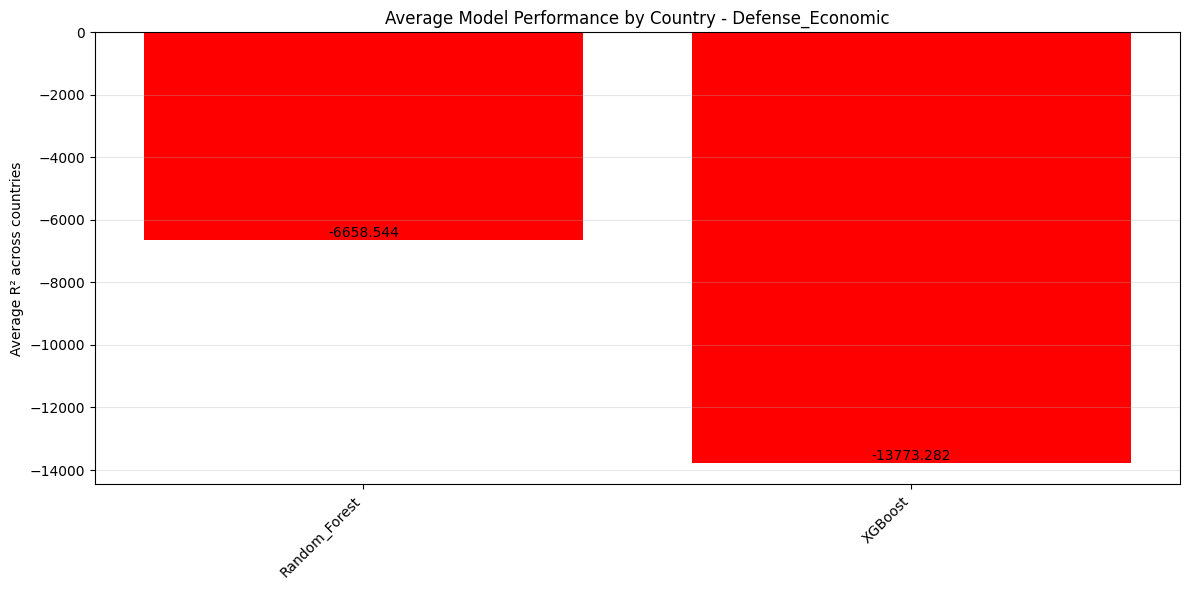


📈 Note: For defense expenditure impact analysis, additional data processing needed.

################################################################################
ANALYZING FEATURE SET: Defense_Social
################################################################################
  Training samples: 130
  Test samples: 25
  Test countries: 5

🤖 TRAINING MODELS...
  Training Linear_Regression...
    Error training Linear_Regression: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https:

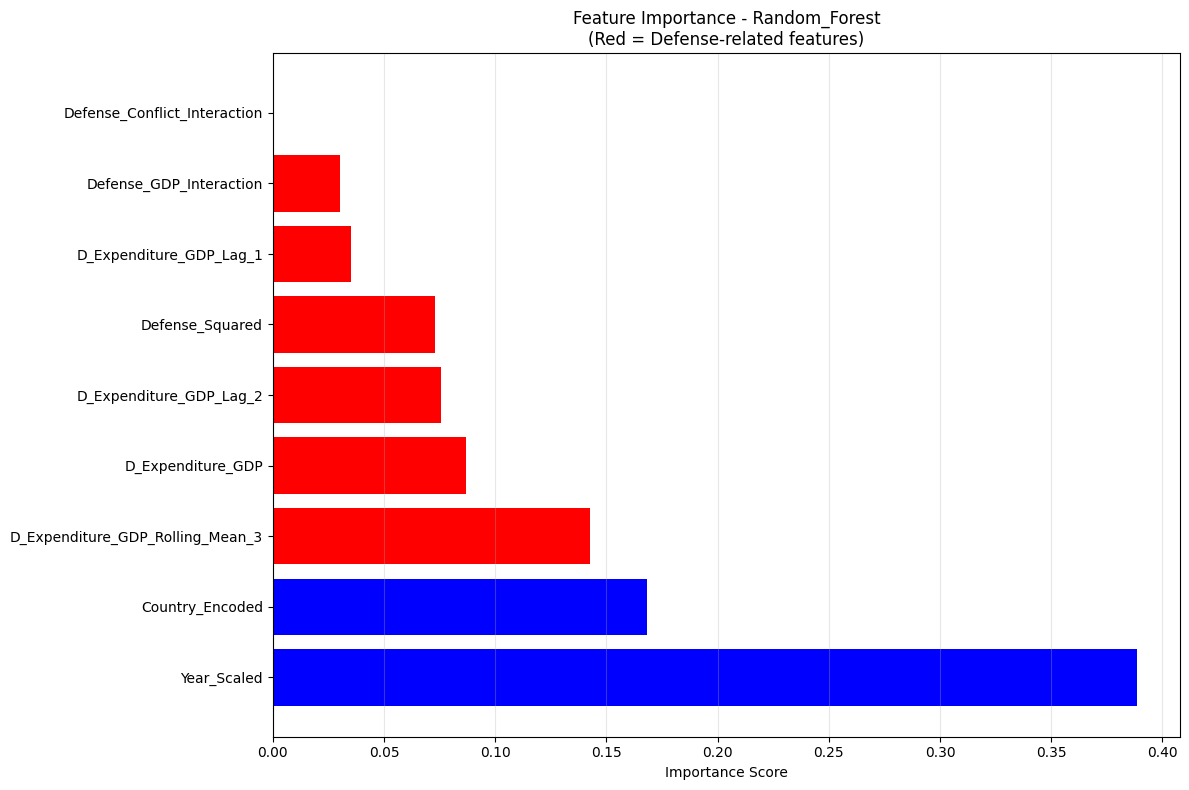


XGBoost - Top 10 Features:
                         Feature  Importance
D_Expenditure_GDP_Rolling_Mean_3    0.552918
                     Year_Scaled    0.253033
                 Country_Encoded    0.126797
               D_Expenditure_GDP    0.048140
         D_Expenditure_GDP_Lag_2    0.012796
         Defense_GDP_Interaction    0.003967
         D_Expenditure_GDP_Lag_1    0.002349
                 Defense_Squared    0.000000
    Defense_Conflict_Interaction    0.000000
  Defense-related features in top 10: 7


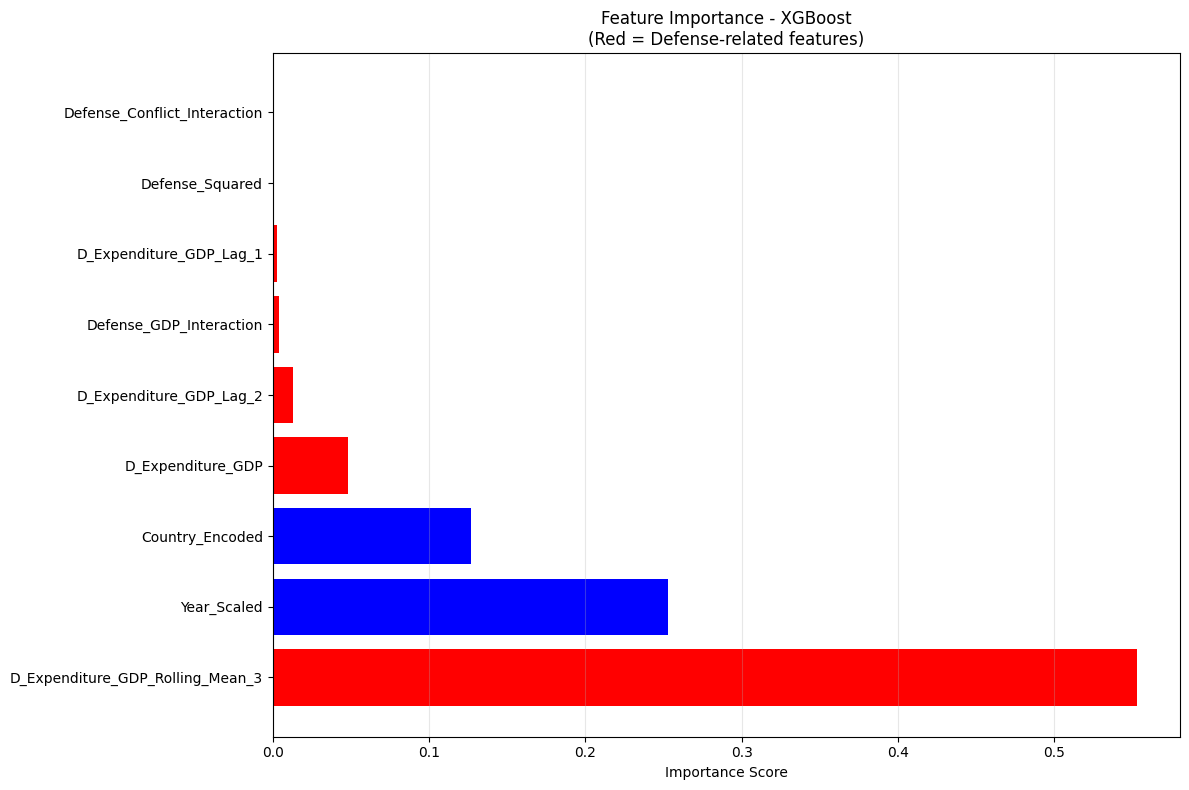


📊 COUNTRY-WISE MODEL EVALUATION - Defense_Social

Random_Forest:
----------------------------------------
  Overall R²:  0.5377
  Overall MAE: 24,066.59
  Overall RMSE: 39,005.97
  Overall MAPE: 636.56%

XGBoost:
----------------------------------------
  Overall R²:  0.7635
  Overall MAE: 13,334.03
  Overall RMSE: 27,900.52
  Overall MAPE: 49.42%

COUNTRY-WISE PERFORMANCE SUMMARY - Defense_Social

Random_Forest:
  Top 3 countries by R²:
    1. RUS: R² = -1.6296
    2. CHN: R² = -5.2806
    3. GBR: R² = -427.7042
  Bottom 3 countries by R²:
    1. GBR: R² = -427.7042
    2. USA: R² = -442.2785
    3. FRA: R² = -1312.0582

XGBoost:
  Top 3 countries by R²:
    1. FRA: R² = -0.6141
    2. GBR: R² = -0.8398
    3. RUS: R² = -0.8749
  Bottom 3 countries by R²:
    1. RUS: R² = -0.8749
    2. CHN: R² = -1.2915
    3. USA: R² = -264.4927

🏆 BEST MODEL FOR EACH COUNTRY:
  CHN: XGBoost (R² = -1.2915)
  FRA: XGBoost (R² = -0.6141)
  GBR: XGBoost (R² = -0.8398)
  RUS: XGBoost (R² = -0.8749)
  U

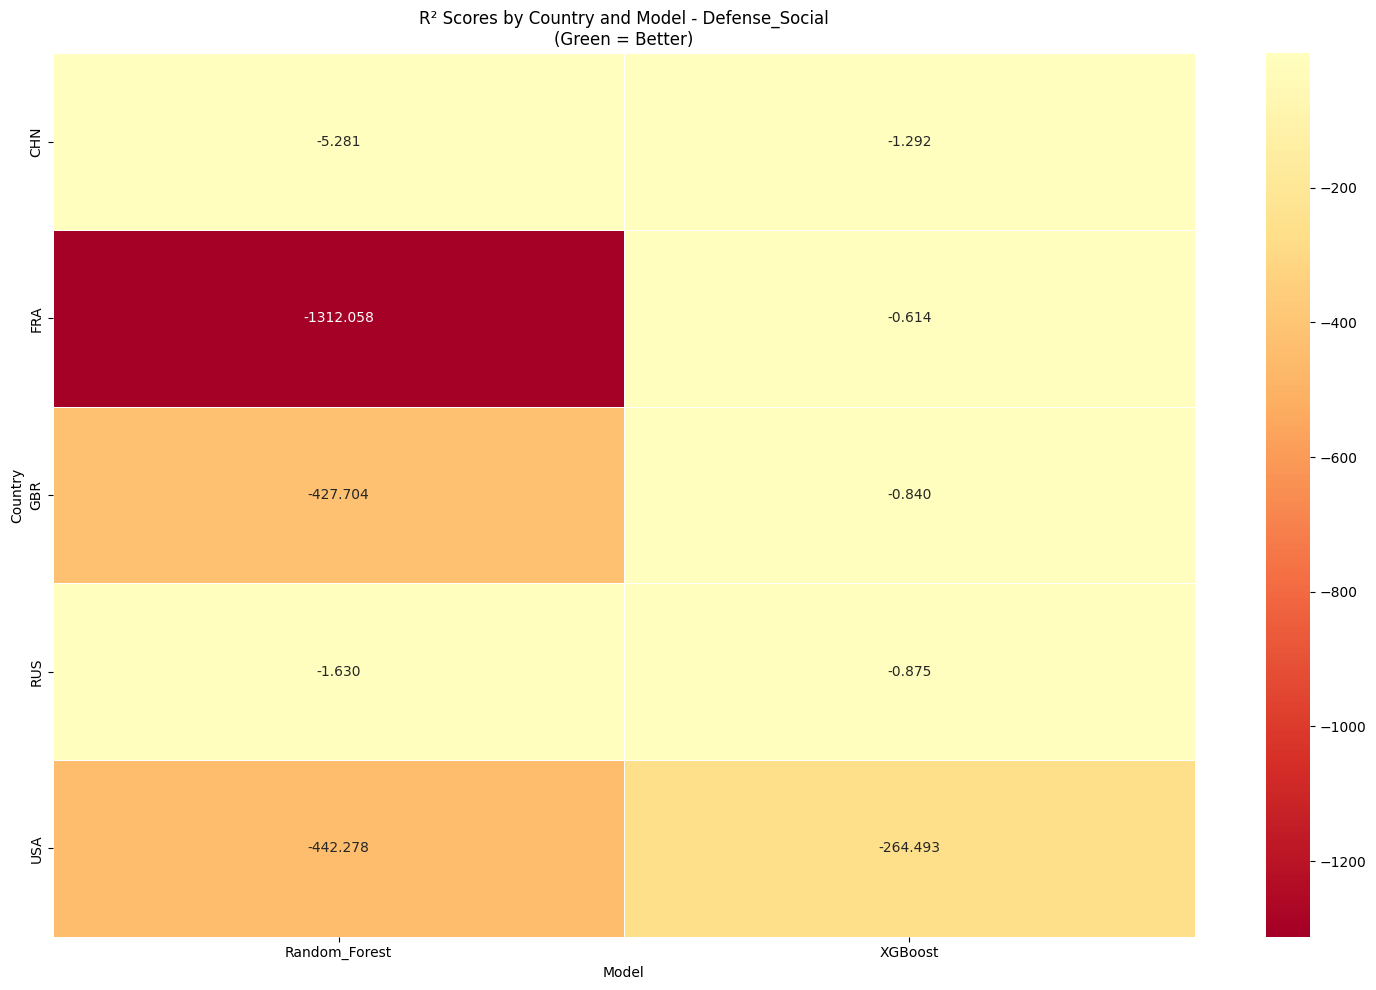

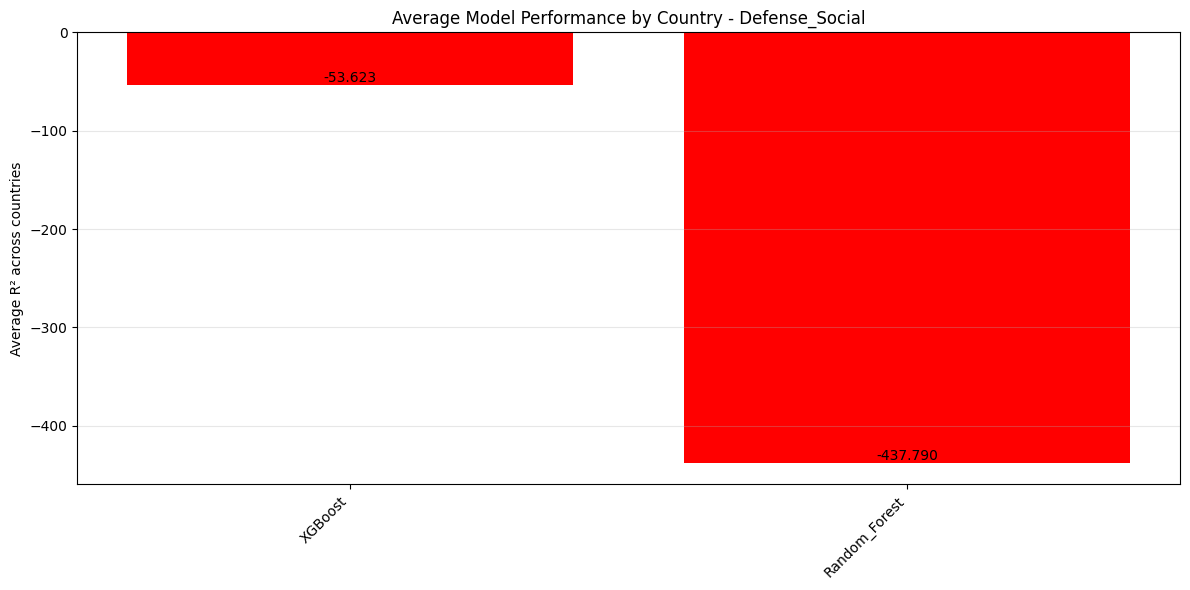


📈 Note: For defense expenditure impact analysis, additional data processing needed.

################################################################################
ANALYZING FEATURE SET: Defense_Migration
################################################################################
  Training samples: 130
  Test samples: 25
  Test countries: 5

🤖 TRAINING MODELS...
  Training Linear_Regression...
    Error training Linear_Regression: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: htt

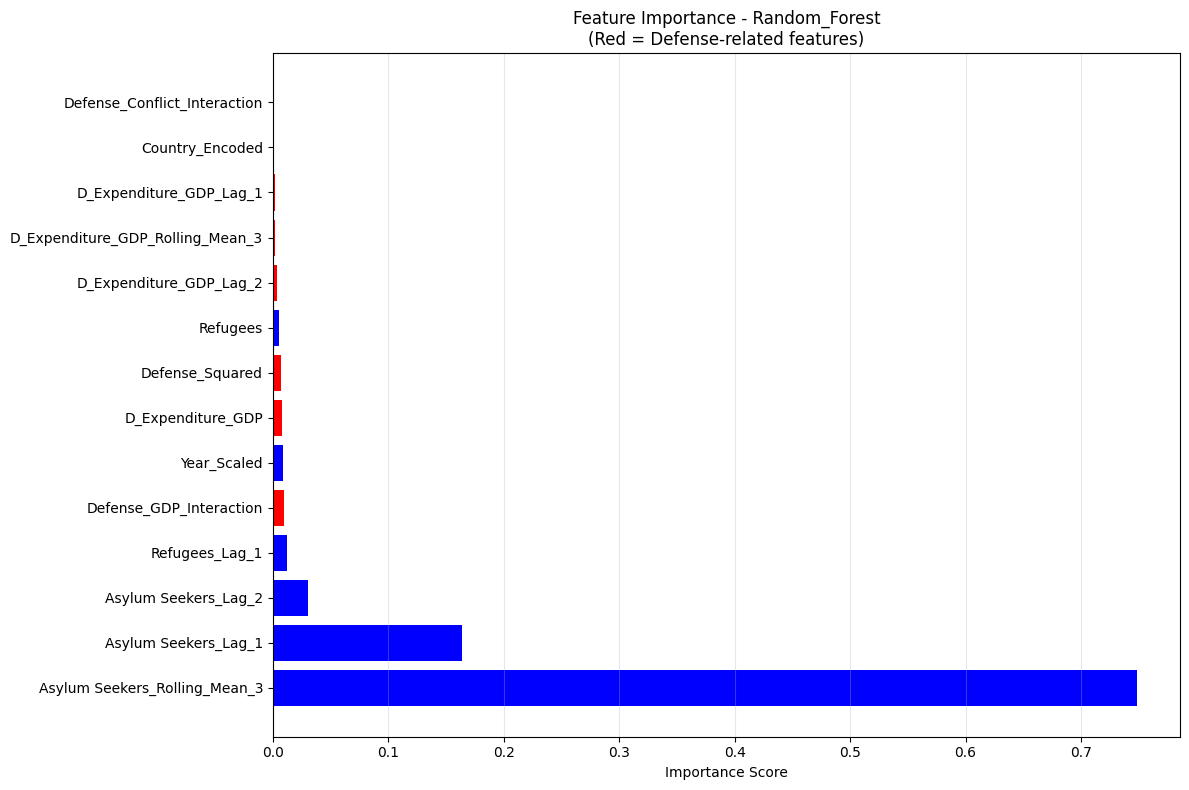


XGBoost - Top 10 Features:
                      Feature  Importance
Asylum Seekers_Rolling_Mean_3    0.718289
               Refugees_Lag_1    0.103665
         Asylum Seekers_Lag_1    0.071160
            D_Expenditure_GDP    0.051794
      Defense_GDP_Interaction    0.038201
                  Year_Scaled    0.006738
         Asylum Seekers_Lag_2    0.003917
                     Refugees    0.003014
      D_Expenditure_GDP_Lag_2    0.002617
      D_Expenditure_GDP_Lag_1    0.000604
  Defense-related features in top 10: 4


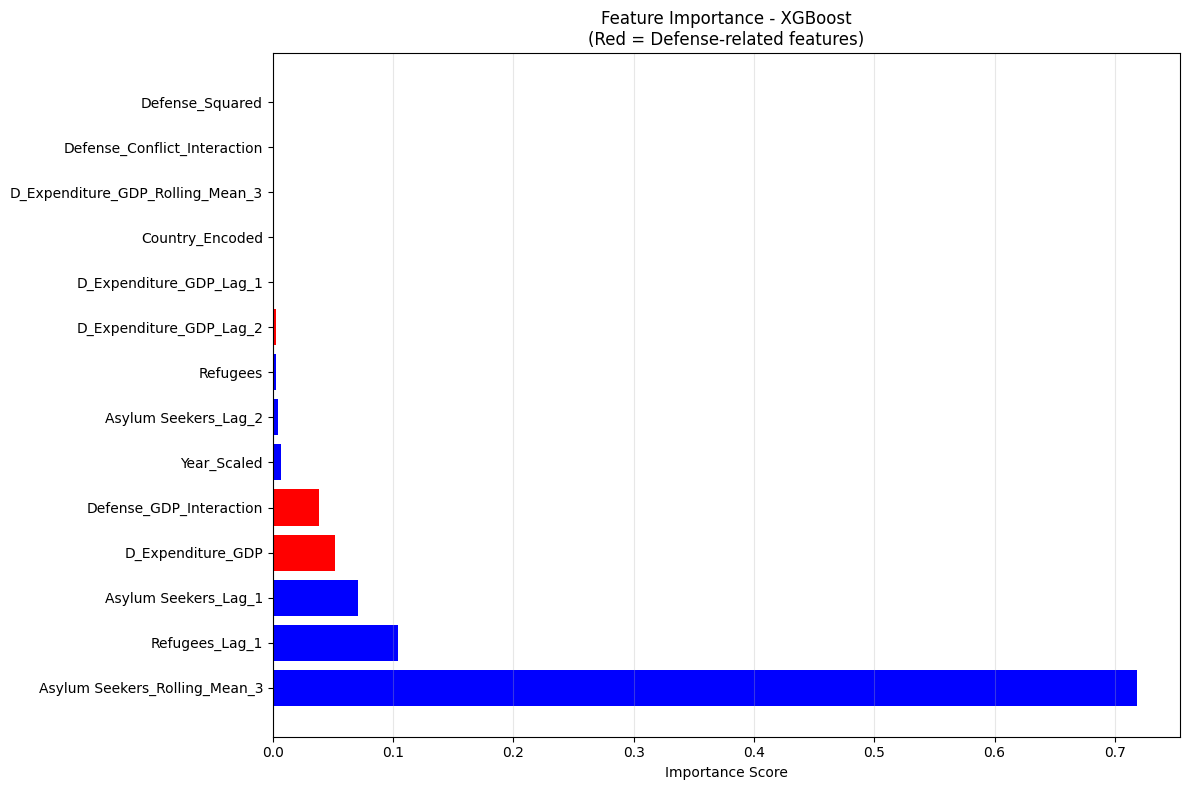


📊 COUNTRY-WISE MODEL EVALUATION - Defense_Migration

Random_Forest:
----------------------------------------
  Overall R²:  0.7177
  Overall MAE: 16,162.41
  Overall RMSE: 30,479.51
  Overall MAPE: 29.82%

XGBoost:
----------------------------------------
  Overall R²:  0.7760
  Overall MAE: 13,920.46
  Overall RMSE: 27,151.70
  Overall MAPE: 29.08%

COUNTRY-WISE PERFORMANCE SUMMARY - Defense_Migration

Random_Forest:
  Top 3 countries by R²:
    1. FRA: R² = 0.6968
    2. GBR: R² = 0.6684
    3. RUS: R² = 0.0008
  Bottom 3 countries by R²:
    1. RUS: R² = 0.0008
    2. CHN: R² = -3.9903
    3. USA: R² = -19.5969

XGBoost:
  Top 3 countries by R²:
    1. FRA: R² = 0.5151
    2. GBR: R² = 0.4428
    3. RUS: R² = -0.0958
  Bottom 3 countries by R²:
    1. RUS: R² = -0.0958
    2. CHN: R² = -2.4188
    3. USA: R² = -6.0950

🏆 BEST MODEL FOR EACH COUNTRY:
  CHN: XGBoost (R² = -2.4188)
  FRA: Random_Forest (R² = 0.6968)
  GBR: Random_Forest (R² = 0.6684)
  RUS: Random_Forest (R² = 0.0008)

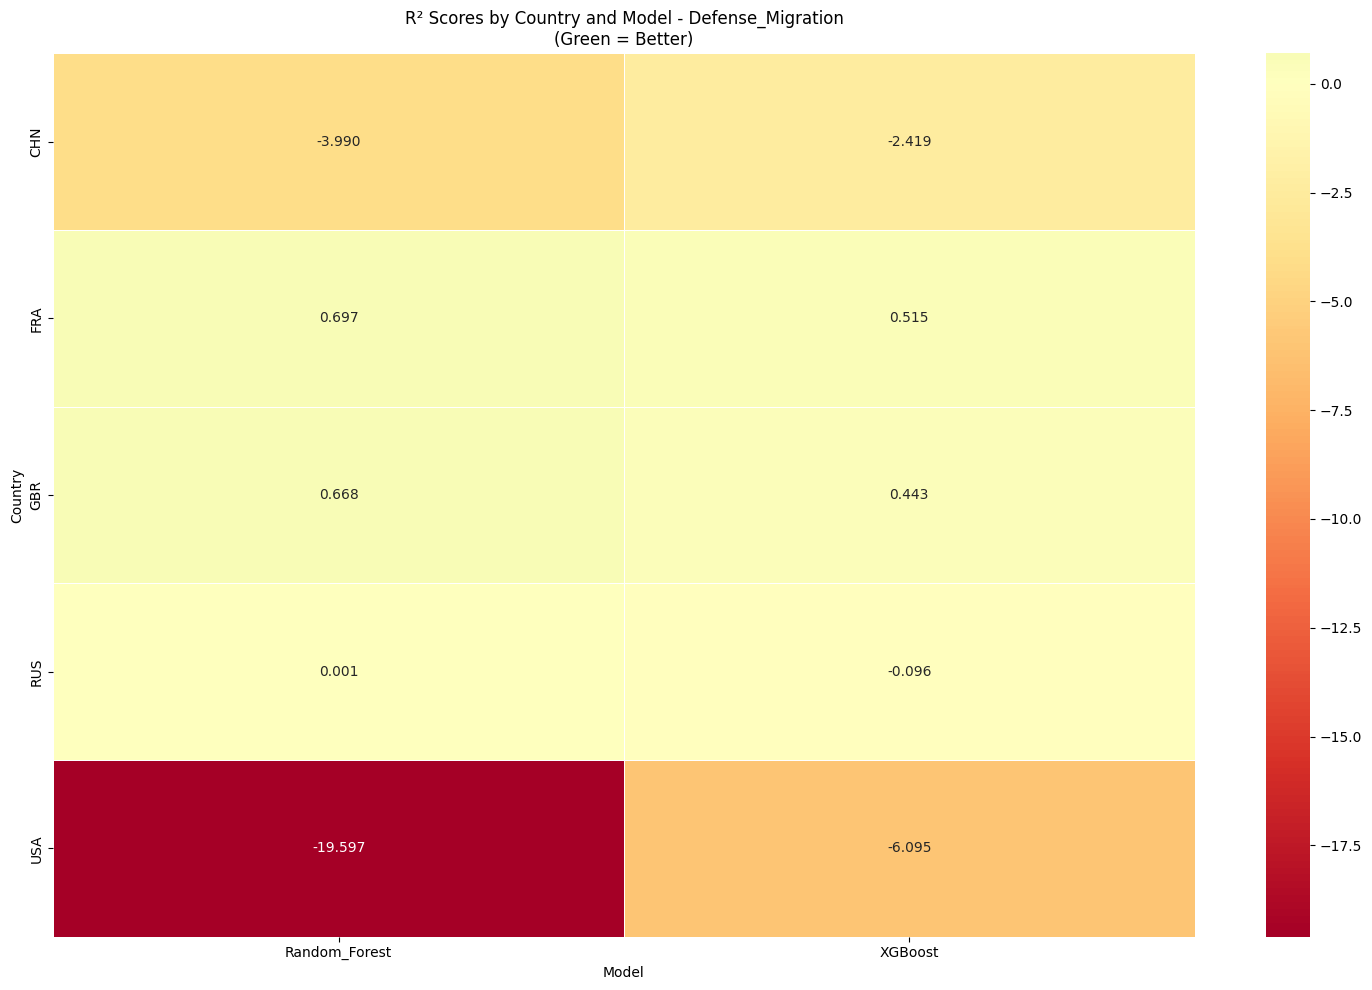

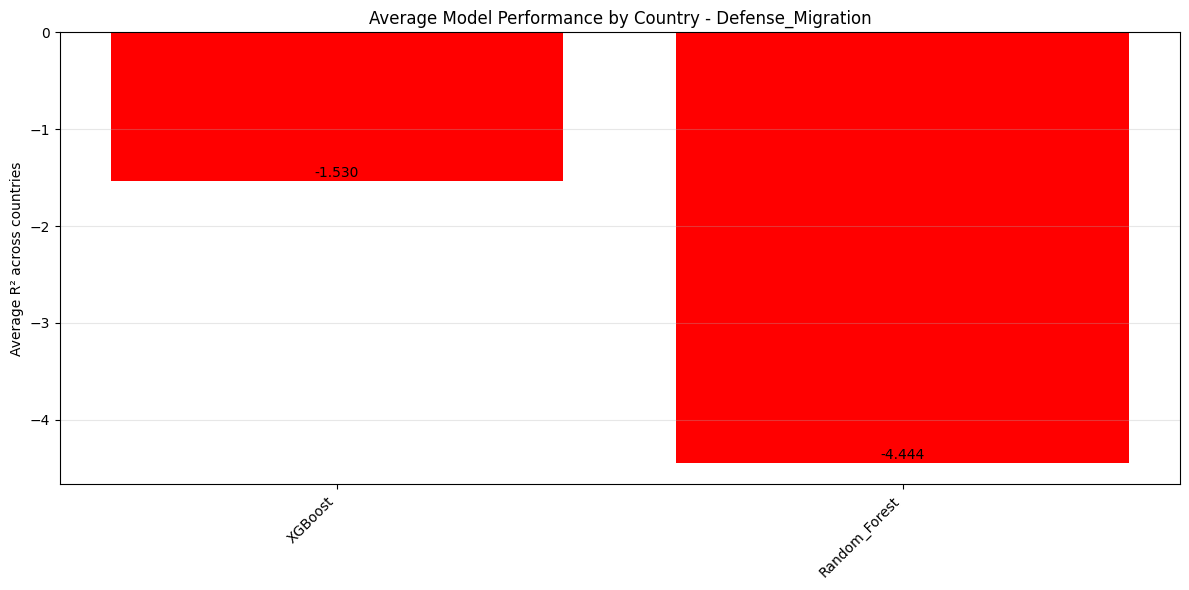


📈 Note: For defense expenditure impact analysis, additional data processing needed.

################################################################################
ANALYZING FEATURE SET: Full_Model
################################################################################
  Training samples: 130
  Test samples: 25
  Test countries: 5

🤖 TRAINING MODELS...
  Training Linear_Regression...
    Error training Linear_Regression: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://sc

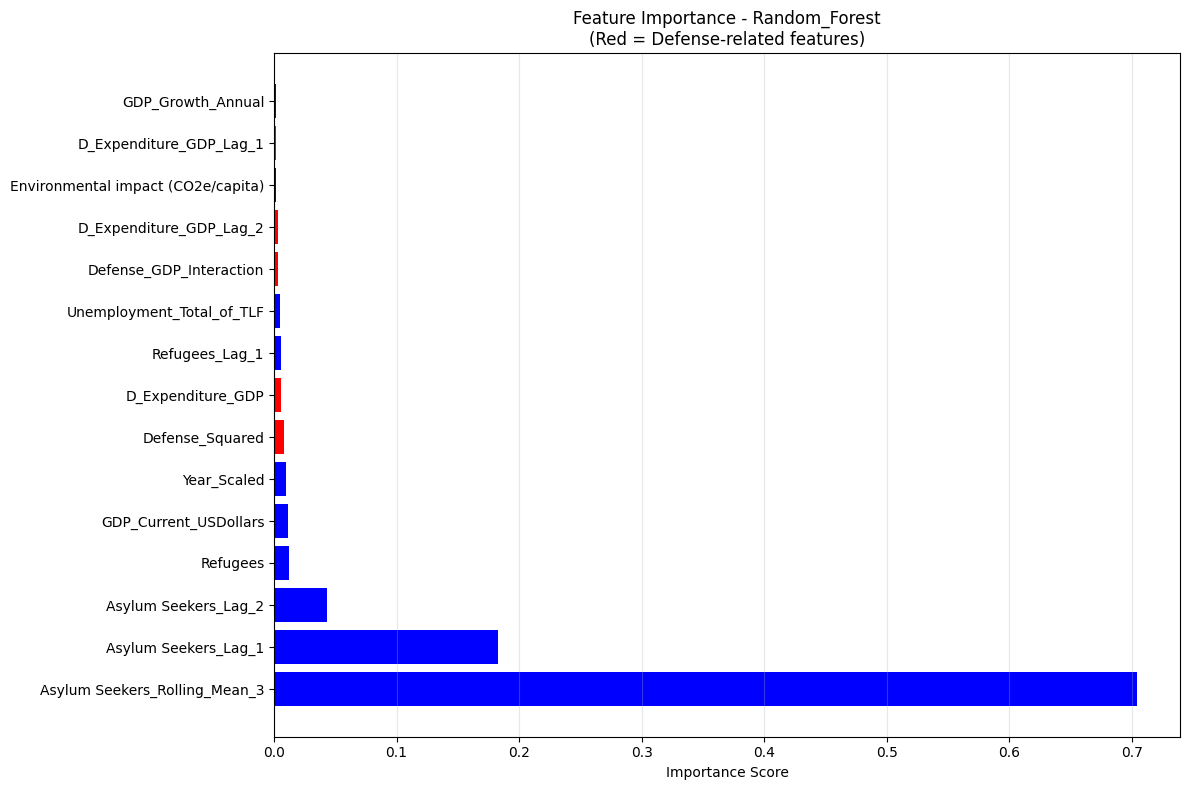


XGBoost - Top 10 Features:
                           Feature  Importance
     Asylum Seekers_Rolling_Mean_3    0.840447
              Asylum Seekers_Lag_1    0.081064
                       Year_Scaled    0.043016
                 GDP_Growth_Annual    0.012053
              Asylum Seekers_Lag_2    0.005258
         Unemployment_Total_of_TLF    0.003812
           D_Expenditure_GDP_Lag_2    0.003308
Environmental impact (CO2e/capita)    0.002629
  D_Expenditure_GDP_Rolling_Mean_3    0.002185
                          Refugees    0.001984
  Defense-related features in top 10: 2


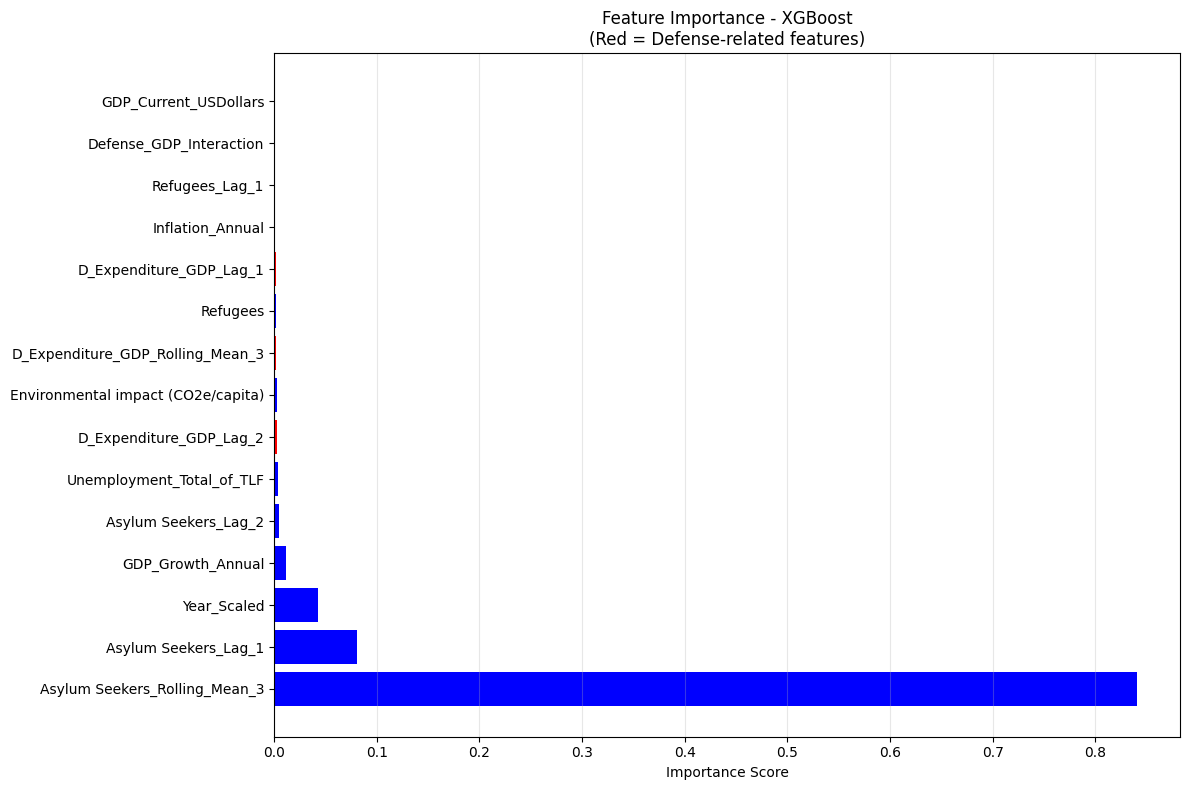


📊 COUNTRY-WISE MODEL EVALUATION - Full_Model

Random_Forest:
----------------------------------------
  Overall R²:  0.7225
  Overall MAE: 16,105.97
  Overall RMSE: 30,221.50
  Overall MAPE: 32.37%

XGBoost:
----------------------------------------
  Overall R²:  0.8672
  Overall MAE: 10,581.70
  Overall RMSE: 20,907.40
  Overall MAPE: 34.79%

COUNTRY-WISE PERFORMANCE SUMMARY - Full_Model

Random_Forest:
  Top 3 countries by R²:
    1. GBR: R² = 0.4910
    2. FRA: R² = 0.4414
    3. RUS: R² = 0.0141
  Bottom 3 countries by R²:
    1. RUS: R² = 0.0141
    2. CHN: R² = -3.8996
    3. USA: R² = -21.7611

XGBoost:
  Top 3 countries by R²:
    1. RUS: R² = 0.5922
    2. GBR: R² = -0.6470
    3. FRA: R² = -0.6710
  Bottom 3 countries by R²:
    1. FRA: R² = -0.6710
    2. CHN: R² = -1.4592
    3. USA: R² = -12.5637

🏆 BEST MODEL FOR EACH COUNTRY:
  CHN: XGBoost (R² = -1.4592)
  FRA: Random_Forest (R² = 0.4414)
  GBR: Random_Forest (R² = 0.4910)
  RUS: XGBoost (R² = 0.5922)
  USA: XGBoost (R

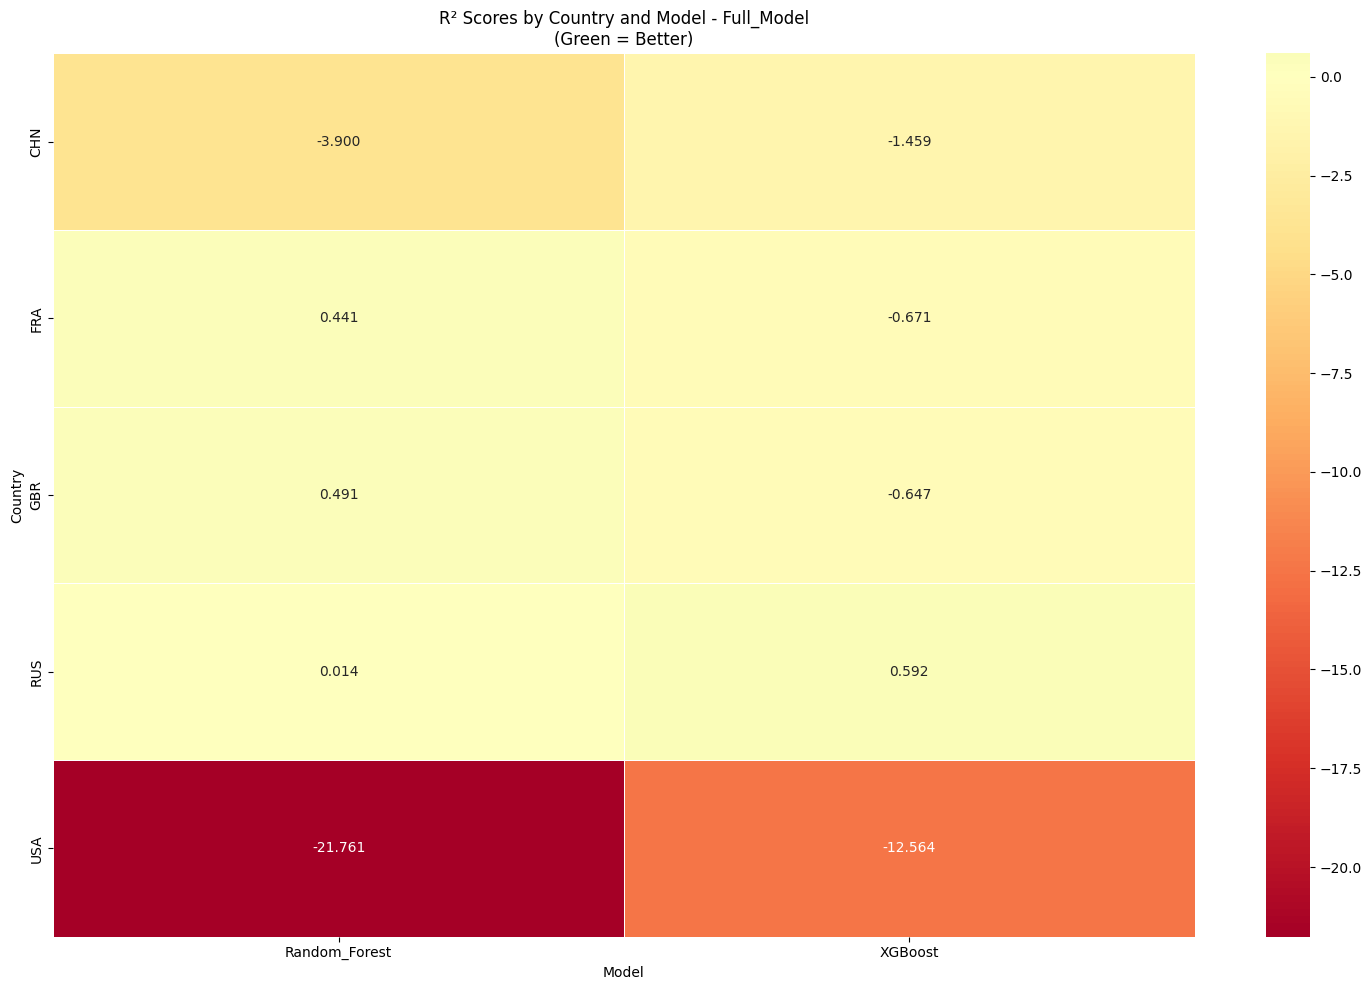

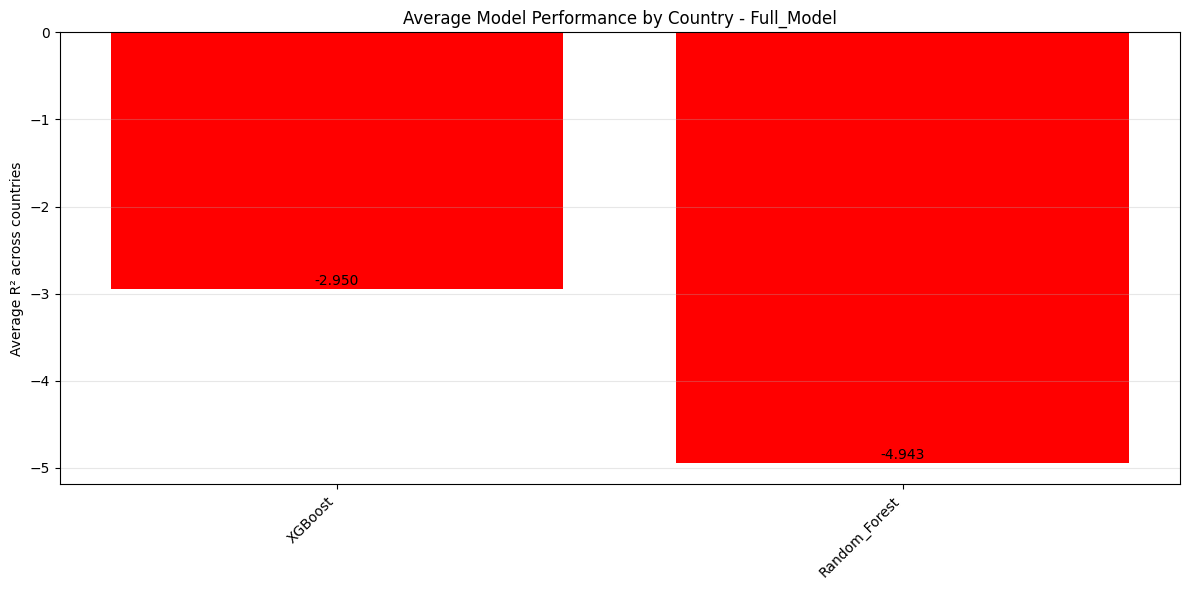


📈 Note: For defense expenditure impact analysis, additional data processing needed.

FEATURE SET COMPARISON

🏆 BEST MODEL FOR EACH FEATURE SET:
  Defense_Only: XGBoost (R² = 0.7635)
  Defense_Economic: XGBoost (R² = 0.5678)
  Defense_Social: XGBoost (R² = 0.7635)
  Defense_Migration: XGBoost (R² = 0.7760)
  Full_Model: XGBoost (R² = 0.8672)


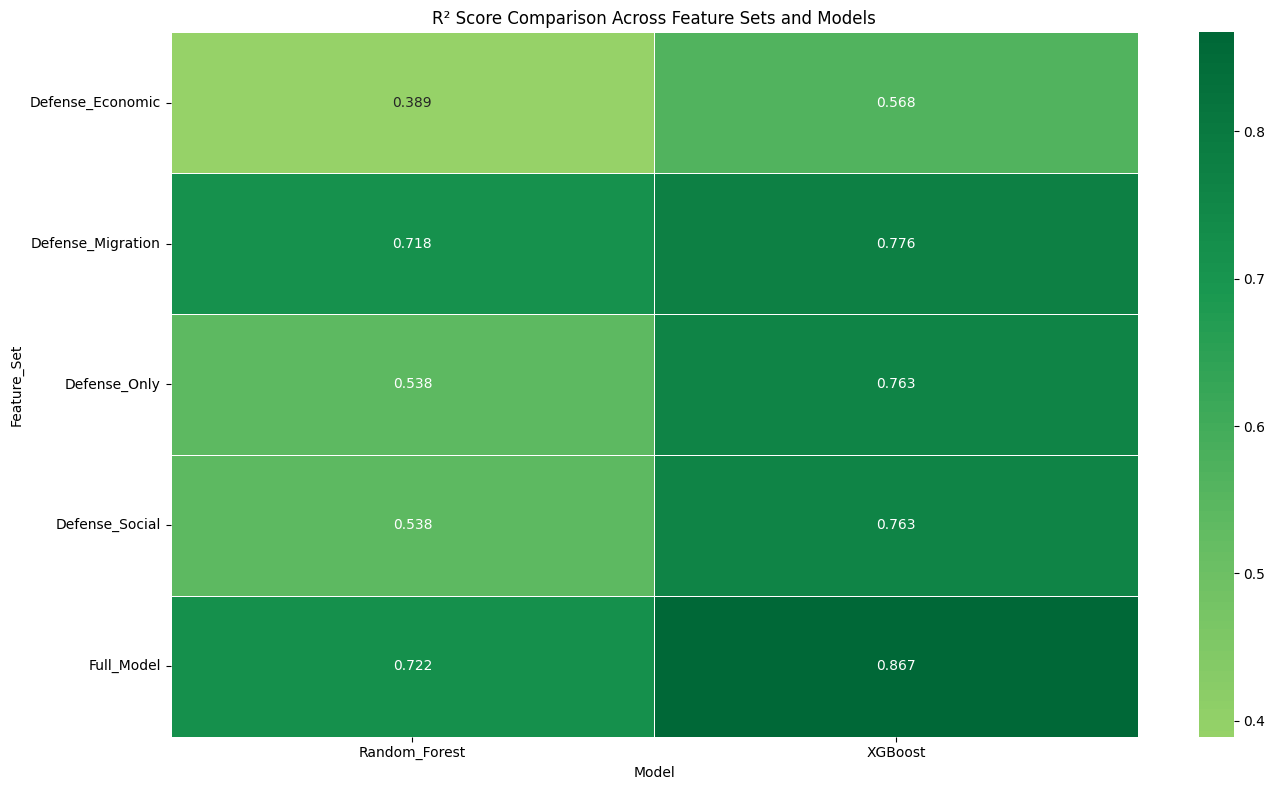


✅ Feature set comparison saved to 'feature_set_comparison.csv'

DEFENSE EXPENDITURE IMPACT ANALYSIS

📈 Overall correlation (Defense %GDP ↔ Asylum Seekers): 0.0355

🏛️ Top 10 Countries by Defense-Asylum Correlation:
  RUS: 0.798 (Positive, n=31)
  GBR: -0.473 (Negative, n=31)
  CHN: -0.315 (Negative, n=31)
  FRA: -0.292 (Negative, n=31)
  USA: -0.102 (Negative, n=31)


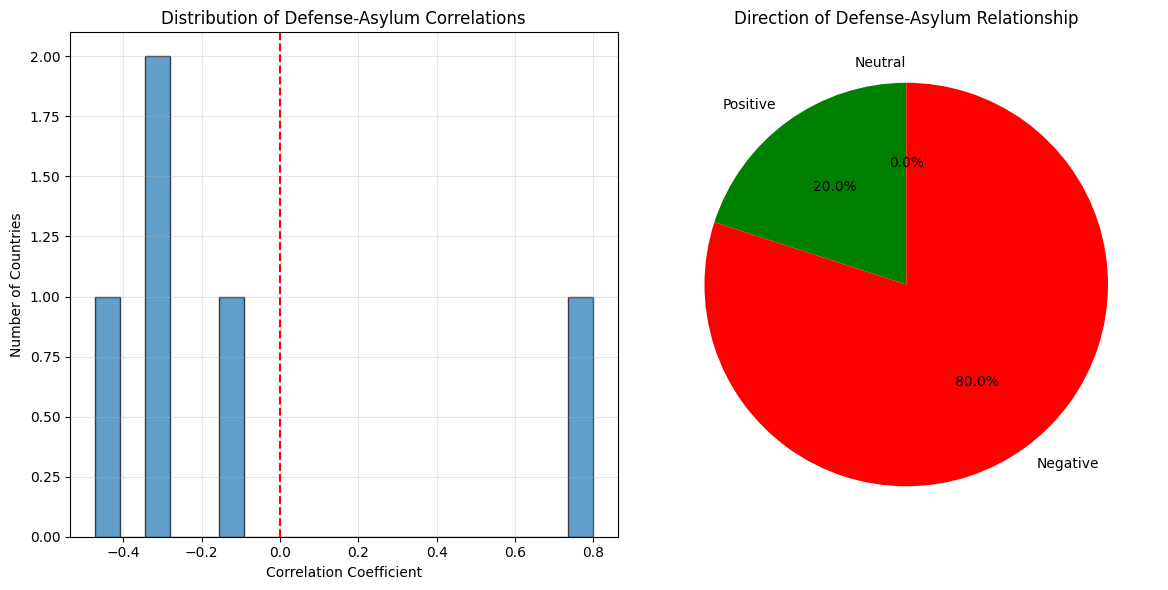


✅ Country-wise correlations saved to 'defense_asylum_correlations_by_country.csv'

ANALYSIS COMPLETE!

📁 FILES CREATED:
  1. country_performance_[feature_set].csv - Country-wise metrics for each feature set
  2. feature_set_comparison.csv - Comparison across all feature sets
  3. defense_asylum_correlations_by_country.csv - Defense impact analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the comprehensive dataset
    """
    print("📁 LOADING DATASET...")
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"✅ Dataset loaded: {df.shape}")
    print(f"Columns: {len(df.columns)} columns")

    # Show first few column names
    print("\nFirst 20 columns:")
    for i, col in enumerate(df.columns[:20]):
        print(f"  {i+1}. {col}")

    return df

def prepare_features(df, target_col='Asylum Seekers'):
    """
    Prepare features for modeling with comprehensive feature engineering
    """
    df_processed = df.copy()

    print("\n🔧 PREPARING FEATURES...")

    # 1. Handle missing values
    print("   Handling missing values...")

    # Different strategies for different columns
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()

    # 4. Create lag features for key variables
    print("   Creating lag features...")
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # Key variables to create lags for
    key_vars = [
        'D_Expenditure_GDP',  # Defense expenditure (% GDP) - YOUR CORE VARIABLE
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Refugees'
    ]

    # Only use variables that exist in the dataset
    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:  # 1, 2, and 3 year lags
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics for defense expenditure and asylum seekers
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP', 'Asylum Seekers']:
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )
            df_processed[f'{var}_Rolling_Std_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).std()
            )

    # 6. Create interaction features with defense expenditure
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        # Interaction with economic indicators
        if 'GDP_Current_USDollars' in df_processed.columns:
            df_processed['Defense_GDP_Interaction'] = df_processed['D_Expenditure_GDP'] * np.log1p(df_processed['GDP_Current_USDollars'])

        # Interaction with conflict
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']

        # Defense expenditure squared (non-linear effect)
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Fill any remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill')

    print(f"✅ Final dataset shape: {df_processed.shape}")
    print(f"✅ Total features created: {len(df_processed.columns)}")

    return df_processed, le_country

# ==========================
# COMPREHENSIVE ASYLUM PREDICTOR WITH COUNTRY-WISE ANALYSIS
# ==========================
class AsylumPredictorWithCountryAnalysis:
    """
    Comprehensive predictor with detailed country-wise performance analysis
    """
    def __init__(self):
        self.models = {}
        self.scalers = {}
        self.results = {}
        self.country_performance = {}

    def prepare_feature_sets(self, df):
        """
        Prepare different feature sets for comparison
        """
        # Base features available in most datasets
        base_features = [
            'Year_Scaled',
            'Country_Encoded',
            'D_Expenditure_GDP',  # Core defense expenditure
        ]

        # Defense-focused features
        defense_features = base_features + [
            'D_Expenditure_GDP_Lag_1',
            'D_Expenditure_GDP_Lag_2',
            'D_Expenditure_GDP_Rolling_Mean_3',
            'Defense_Squared',
        ]

        # Add interaction features if they exist
        if 'Defense_GDP_Interaction' in df.columns:
            defense_features.append('Defense_GDP_Interaction')
        if 'Defense_Conflict_Interaction' in df.columns:
            defense_features.append('Defense_Conflict_Interaction')

        # Economic features
        economic_features = defense_features.copy()
        economic_features.extend([
            'GDP_Current_USDollars',
            'GDP_Growth_Annual',
            'Inflation_Annual',
            'Unemployment_Total_of_TLF',
        ])

        # Social features
        social_features = defense_features.copy()
        social_features.extend([
            'Health_Expenditure_GDP',
            'Education_Expenditure_GDP',
            'Secondary_SclEnroll_Gross _%',
        ])

        # Environmental features
        environmental_features = defense_features.copy()
        env_cols = [col for col in df.columns if 'Environmental' in col or 'PM2.5' in col or 'CO2' in col]
        environmental_features.extend(env_cols)

        # Migration features
        migration_features = defense_features.copy()
        migration_features.extend([
            'Refugees',
            'Refugees_Lag_1',
            'Asylum Seekers_Lag_1',
            'Asylum Seekers_Lag_2',
            'Asylum Seekers_Rolling_Mean_3',
        ])

        # Full feature set
        full_features = list(set(
            defense_features +
            economic_features +
            social_features +
            environmental_features +
            migration_features
        ))

        # Filter to features that actually exist in the dataframe
        feature_sets = {}
        for name, features in [
            ('Defense_Only', defense_features),
            ('Defense_Economic', economic_features),
            ('Defense_Social', social_features),
            ('Defense_Migration', migration_features),
            ('Full_Model', full_features)
        ]:
            available_features = [f for f in features if f in df.columns]
            if available_features:
                feature_sets[name] = available_features

        print(f"\n📋 FEATURE SETS CREATED:")
        for name, features in feature_sets.items():
            print(f"  {name}: {len(features)} features")
            if len(features) <= 10:
                print(f"    {features}")

        return feature_sets

    def train_models(self, X_train, y_train, feature_names):
        """
        Train multiple models for comparison
        """
        print("\n🤖 TRAINING MODELS...")

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        self.scalers['standard'] = scaler

        # Define models with optimized parameters
        models = {
            'Linear_Regression': LinearRegression(),
            'Ridge_Regression': Ridge(alpha=1.0, random_state=42),
            'Lasso_Regression': Lasso(alpha=0.01, random_state=42, max_iter=10000),
            'Random_Forest': RandomForestRegressor(
                n_estimators=200,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ),
            'Gradient_Boosting': GradientBoostingRegressor(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=5,
                random_state=42
            ),
            'XGBoost': XGBRegressor(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=5,
                random_state=42,
                n_jobs=-1
            ),
            'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
            'Neural_Network': MLPRegressor(
                hidden_layer_sizes=(100, 50),
                activation='relu',
                solver='adam',
                max_iter=1000,
                random_state=42
            )
        }

        for name, model in models.items():
            print(f"  Training {name}...")
            try:
                model.fit(X_train_scaled, y_train)
                self.models[name] = model
            except Exception as e:
                print(f"    Error training {name}: {e}")

        print(f"✅ Trained {len(self.models)} models")

        # Feature importance for tree-based models
        self.calculate_feature_importance(feature_names)

        return self.models

    def calculate_feature_importance(self, feature_names):
        """
        Calculate and display feature importance
        """
        print("\n🔍 FEATURE IMPORTANCE ANALYSIS:")

        for name, model in self.models.items():
            if hasattr(model, 'feature_importances_'):
                importance = pd.DataFrame({
                    'Feature': feature_names,
                    'Importance': model.feature_importances_
                }).sort_values('Importance', ascending=False)

                print(f"\n{name} - Top 10 Features:")
                print(importance.head(10).to_string(index=False))

                # Check if defense expenditure is in top features
                defense_features = [f for f in importance.head(10)['Feature']
                                  if 'D_Expenditure' in f or 'Defense' in f]
                if defense_features:
                    print(f"  Defense-related features in top 10: {len(defense_features)}")

                # Plot feature importance
                plt.figure(figsize=(12, 8))
                top_features = importance.head(15)
                colors = ['red' if ('D_Expenditure' in f or 'Defense' in f) else 'blue'
                         for f in top_features['Feature']]

                plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
                plt.yticks(range(len(top_features)), top_features['Feature'])
                plt.xlabel('Importance Score')
                plt.title(f'Feature Importance - {name}\n(Red = Defense-related features)')
                plt.grid(True, alpha=0.3, axis='x')
                plt.tight_layout()
                plt.show()

    def evaluate_models_country_wise(self, X_test, y_test, countries_test, feature_set_name):
        """
        Evaluate models with detailed country-wise performance
        """
        print(f"\n📊 COUNTRY-WISE MODEL EVALUATION - {feature_set_name}")
        print("="*80)

        # Scale test features
        X_test_scaled = self.scalers['standard'].transform(X_test)

        # Create a dataframe for test data with countries
        test_data = pd.DataFrame(X_test, columns=X_test.columns if hasattr(X_test, 'columns') else range(X_test.shape[1]))
        test_data['Actual'] = y_test
        test_data['Country'] = countries_test

        # Initialize results storage
        country_results = {}
        overall_results = {}

        for model_name, model in self.models.items():
            print(f"\n{model_name}:")
            print("-" * 40)

            # Overall predictions
            y_pred = model.predict(X_test_scaled)

            # Overall metrics
            overall_metrics = {
                'R2': r2_score(y_test, y_pred),
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
                'MAPE': self.calculate_mape(y_test, y_pred)
            }

            overall_results[model_name] = overall_metrics

            print(f"  Overall R²:  {overall_metrics['R2']:.4f}")
            print(f"  Overall MAE: {overall_metrics['MAE']:,.2f}")
            print(f"  Overall RMSE: {overall_metrics['RMSE']:,.2f}")
            print(f"  Overall MAPE: {overall_metrics['MAPE']:.2f}%")

            # Country-wise metrics
            model_country_results = {}

            for country in test_data['Country'].unique():
                country_mask = test_data['Country'] == country
                if country_mask.sum() > 0:  # Ensure we have data for this country
                    y_true_country = test_data.loc[country_mask, 'Actual']
                    y_pred_country = y_pred[country_mask]

                    # Calculate country-specific metrics
                    if len(y_true_country) > 1:  # Need at least 2 samples for R²
                        country_r2 = r2_score(y_true_country, y_pred_country)
                    else:
                        country_r2 = np.nan

                    country_mae = mean_absolute_error(y_true_country, y_pred_country)
                    country_rmse = np.sqrt(mean_squared_error(y_true_country, y_pred_country))
                    country_mape = self.calculate_mape(y_true_country, y_pred_country)

                    model_country_results[country] = {
                        'R2': country_r2,
                        'MAE': country_mae,
                        'RMSE': country_rmse,
                        'MAPE': country_mape,
                        'Samples': len(y_true_country)
                    }

            country_results[model_name] = model_country_results

        # Store results
        self.results[feature_set_name] = {
            'overall': overall_results,
            'country_wise': country_results
        }

        # Print country-wise summary
        self.print_country_performance_summary(country_results, feature_set_name)

        # Create country-wise visualizations
        self.visualize_country_performance(country_results, feature_set_name)

        return overall_results, country_results

    def print_country_performance_summary(self, country_results, feature_set_name):
        """
        Print summary of country-wise performance
        """
        print(f"\n{'='*80}")
        print(f"COUNTRY-WISE PERFORMANCE SUMMARY - {feature_set_name}")
        print('='*80)

        # Get all unique countries
        all_countries = set()
        for model_results in country_results.values():
            all_countries.update(model_results.keys())

        # Convert to sorted list
        all_countries = sorted(list(all_countries))

        # Create summary dataframe
        summary_data = []

        for country in all_countries:
            country_metrics = {}

            for model_name, model_results in country_results.items():
                if country in model_results:
                    country_metrics[f'{model_name}_R2'] = model_results[country]['R2']
                    country_metrics[f'{model_name}_MAPE'] = model_results[country]['MAPE']
                else:
                    country_metrics[f'{model_name}_R2'] = np.nan
                    country_metrics[f'{model_name}_MAPE'] = np.nan

            country_metrics['Country'] = country

            # Count how many models have data for this country
            valid_models = sum(1 for model_name in country_results.keys()
                             if country in country_results[model_name])
            country_metrics['Valid_Models'] = valid_models

            summary_data.append(country_metrics)

        summary_df = pd.DataFrame(summary_data)

        # Print top and bottom performing countries for each model
        for model_name in country_results.keys():
            model_r2_col = f'{model_name}_R2'
            if model_r2_col in summary_df.columns:
                # Sort by R² for this model
                model_df = summary_df[['Country', model_r2_col]].dropna().sort_values(
                    model_r2_col, ascending=False
                )

                if len(model_df) > 0:
                    print(f"\n{model_name}:")
                    print(f"  Top 3 countries by R²:")
                    for i, (country, r2) in enumerate(model_df.head(3).values):
                        print(f"    {i+1}. {country}: R² = {r2:.4f}")

                    print(f"  Bottom 3 countries by R²:")
                    for i, (country, r2) in enumerate(model_df.tail(3).values):
                        print(f"    {i+1}. {country}: R² = {r2:.4f}")

        # Find best model for each country
        print(f"\n BEST MODEL FOR EACH COUNTRY:")
        for country in all_countries[:15]:  # Show first 15 countries
            best_model = None
            best_r2 = -np.inf

            for model_name, model_results in country_results.items():
                if country in model_results:
                    r2 = model_results[country]['R2']
                    if not np.isnan(r2) and r2 > best_r2:
                        best_r2 = r2
                        best_model = model_name

            if best_model:
                print(f"  {country}: {best_model} (R² = {best_r2:.4f})")

        # Save summary to CSV
        summary_df.to_csv(f'country_performance_{feature_set_name}.csv', index=False)
        print(f"\n Country-wise performance saved to 'country_performance_{feature_set_name}.csv'")

        return summary_df

    def visualize_country_performance(self, country_results, feature_set_name):
        """
        Create visualizations for country-wise performance
        """
        # 1. Heatmap of R² scores by country and model
        all_countries = sorted(set().union(*[set(results.keys()) for results in country_results.values()]))
        all_models = list(country_results.keys())

        r2_matrix = pd.DataFrame(index=all_countries, columns=all_models)

        for model in all_models:
            for country in all_countries:
                if country in country_results[model]:
                    r2_matrix.loc[country, model] = country_results[model][country]['R2']
                else:
                    r2_matrix.loc[country, model] = np.nan

        # Plot heatmap
        plt.figure(figsize=(15, max(10, len(all_countries) * 0.3)))
        sns.heatmap(r2_matrix.astype(float), annot=True, fmt='.3f',
                   cmap='RdYlGn', center=0, linewidths=0.5)
        plt.title(f'R² Scores by Country and Model - {feature_set_name}\n(Green = Better)')
        plt.xlabel('Model')
        plt.ylabel('Country')
        plt.tight_layout()
        plt.show()

        # 2. Bar chart of average R² by model across countries
        avg_r2_by_model = {}
        for model in all_models:
            r2_values = []
            for country in all_countries:
                if country in country_results[model]:
                    r2 = country_results[model][country]['R2']
                    if not np.isnan(r2):
                        r2_values.append(r2)

            if r2_values:
                avg_r2_by_model[model] = np.mean(r2_values)

        if avg_r2_by_model:
            plt.figure(figsize=(12, 6))
            models_sorted = sorted(avg_r2_by_model.items(), key=lambda x: x[1], reverse=True)
            models, avg_r2 = zip(*models_sorted)

            colors = ['green' if r2 > 0 else 'red' for r2 in avg_r2]
            bars = plt.bar(range(len(models)), avg_r2, color=colors)

            plt.xticks(range(len(models)), models, rotation=45, ha='right')
            plt.ylabel('Average R² across countries')
            plt.title(f'Average Model Performance by Country - {feature_set_name}')
            plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

            # Add value labels on bars
            for bar, r2 in zip(bars, avg_r2):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{r2:.3f}', ha='center', va='bottom')

            plt.grid(True, alpha=0.3, axis='y')
            plt.tight_layout()
            plt.show()

        # 3. Defense expenditure vs model performance scatter
        # (This would require defense expenditure data for each country)
        print(f"\n Note: For defense expenditure impact analysis, additional data processing needed.")

    def calculate_mape(self, y_true, y_pred):
        """
        Calculate Mean Absolute Percentage Error
        """
        # Avoid division by zero
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Filter out zeros
        mask = y_true != 0
        if np.sum(mask) == 0:
            return np.nan

        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    def run_comprehensive_analysis(self, df, target_col='Asylum Seekers'):
        """
        Run comprehensive analysis with country-wise evaluation
        """
        print("COMPREHENSIVE ASYLUM PREDICTOR WITH COUNTRY-WISE ANALYSIS")
        print("="*80)

        # Prepare feature sets
        feature_sets = self.prepare_feature_sets(df)

        # Define test years (most recent years for time series validation)
        all_years = sorted(df['Year'].unique())
        test_years = all_years[-5:] if len(all_years) >= 10 else all_years[-3:]

        print(f"\n Time Series Split:")
        print(f"  Training years: {min(all_years)} - {max(test_years)-1}")
        print(f"  Test years: {min(test_years)} - {max(test_years)}")

        all_results = {}

        for feature_set_name, features in feature_sets.items():
            print(f"\n{'#'*80}")
            print(f"ANALYZING FEATURE SET: {feature_set_name}")
            print(f"{'#'*80}")

            # Prepare features and target
            X = df[features]
            y = df[target_col]
            countries = df['Country']

            # Split by time (not random for time series)
            train_mask = ~df['Year'].isin(test_years)
            test_mask = df['Year'].isin(test_years)

            X_train = X[train_mask]
            X_test = X[test_mask]
            y_train = y[train_mask]
            y_test = y[test_mask]
            countries_test = countries[test_mask]

            print(f"  Training samples: {len(X_train)}")
            print(f"  Test samples: {len(X_test)}")
            print(f"  Test countries: {len(countries_test.unique())}")

            # Train models
            models = self.train_models(X_train, y_train, features)

            # Evaluate with country-wise analysis
            overall_results, country_results = self.evaluate_models_country_wise(
                X_test, y_test, countries_test, feature_set_name
            )

            all_results[feature_set_name] = {
                'overall': overall_results,
                'country_wise': country_results
            }

        # Compare feature sets
        self.compare_feature_sets(all_results)

        # Defense expenditure impact analysis
        self.analyze_defense_impact(df, all_results)

        return all_results

    def compare_feature_sets(self, all_results):
        """
        Compare performance across different feature sets
        """
        print(f"\n{'='*80}")
        print("FEATURE SET COMPARISON")
        print('='*80)

        comparison_data = []

        for feature_set, results in all_results.items():
            for model_name, metrics in results['overall'].items():
                comparison_data.append({
                    'Feature_Set': feature_set,
                    'Model': model_name,
                    'R2': metrics['R2'],
                    'MAE': metrics['MAE'],
                    'RMSE': metrics['RMSE']
                })

        comparison_df = pd.DataFrame(comparison_data)

        # Print best model for each feature set
        print("\n🏆 BEST MODEL FOR EACH FEATURE SET:")
        for feature_set in all_results.keys():
            best_model = None
            best_r2 = -np.inf

            for model_name, metrics in all_results[feature_set]['overall'].items():
                if metrics['R2'] > best_r2:
                    best_r2 = metrics['R2']
                    best_model = model_name

            if best_model:
                print(f"  {feature_set}: {best_model} (R² = {best_r2:.4f})")

        # Create comparison visualization
        if not comparison_df.empty:
            plt.figure(figsize=(14, 8))

            # Pivot for heatmap
            pivot_r2 = comparison_df.pivot(index='Feature_Set', columns='Model', values='R2')

            sns.heatmap(pivot_r2, annot=True, fmt='.3f', cmap='RdYlGn',
                       center=0, linewidths=0.5)
            plt.title('R² Score Comparison Across Feature Sets and Models')
            plt.tight_layout()
            plt.show()

        # Save comparison
        comparison_df.to_csv('feature_set_comparison.csv', index=False)
        print(f"\n✅ Feature set comparison saved to 'feature_set_comparison.csv'")

    def analyze_defense_impact(self, df, all_results):
        """
        Special analysis for defense expenditure impact
        """
        print(f"\n{'='*80}")
        print("DEFENSE EXPENDITURE IMPACT ANALYSIS")
        print('='*80)

        if 'D_Expenditure_GDP' not in df.columns:
            print("  Defense expenditure data not available in dataset")
            return

        # 1. Overall correlation
        defense_corr = df['D_Expenditure_GDP'].corr(df['Asylum Seekers'])
        print(f"\n📈 Overall correlation (Defense %GDP ↔ Asylum Seekers): {defense_corr:.4f}")

        # 2. Country-specific correlations
        country_correlations = []

        for country in df['Country'].unique():
            country_data = df[df['Country'] == country]
            if len(country_data) > 5:
                corr = country_data['D_Expenditure_GDP'].corr(country_data['Asylum Seekers'])
                country_correlations.append({
                    'Country': country,
                    'Correlation': corr,
                    'Abs_Correlation': abs(corr),
                    'Direction': 'Positive' if corr > 0 else 'Negative',
                    'Samples': len(country_data)
                })

        if country_correlations:
            corr_df = pd.DataFrame(country_correlations).sort_values('Abs_Correlation', ascending=False)

            print(f"\n🏛️ Top 10 Countries by Defense-Asylum Correlation:")
            for i, row in corr_df.head(10).iterrows():
                print(f"  {row['Country']}: {row['Correlation']:.3f} ({row['Direction']}, n={row['Samples']})")

            # Plot distribution of correlations
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.hist(corr_df['Correlation'], bins=20, edgecolor='black', alpha=0.7)
            plt.axvline(x=0, color='red', linestyle='--')
            plt.xlabel('Correlation Coefficient')
            plt.ylabel('Number of Countries')
            plt.title('Distribution of Defense-Asylum Correlations')
            plt.grid(True, alpha=0.3)

            plt.subplot(1, 2, 2)
            positive_count = (corr_df['Correlation'] > 0).sum()
            negative_count = (corr_df['Correlation'] < 0).sum()
            neutral_count = (corr_df['Correlation'] == 0).sum()

            labels = ['Positive', 'Negative', 'Neutral']
            sizes = [positive_count, negative_count, neutral_count]
            colors = ['green', 'red', 'gray']

            plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
            plt.title('Direction of Defense-Asylum Relationship')

            plt.tight_layout()
            plt.show()

            # Save correlations
            corr_df.to_csv('defense_asylum_correlations_by_country.csv', index=False)
            print(f"\n✅ Country-wise correlations saved to 'defense_asylum_correlations_by_country.csv'")

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    # Load your dataset
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'

    # Load data
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_features(df)

    # Run comprehensive analysis
    predictor = AsylumPredictorWithCountryAnalysis()
    results = predictor.run_comprehensive_analysis(df_processed)

    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE!")
    print('='*80)

    # Summary of files created
    print("\n📁 FILES CREATED:")
    print("  1. country_performance_[feature_set].csv - Country-wise metrics for each feature set")
    print("  2. feature_set_comparison.csv - Comparison across all feature sets")
    print("  3. defense_asylum_correlations_by_country.csv - Defense impact analysis")

    return predictor, results

# Run the analysis
if __name__ == "__main__":
    predictor, results = main()